# Prepare the data

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [77]:
record=pd.read_csv("Record.csv")
client=pd.read_csv("Client.csv")

In [78]:
print(record.head())
print(client.head())

   rev_Mean  mou_Mean  totmrc_Mean  da_Mean  ovrmou_Mean  ovrrev_Mean  \
0   23.9975    219.25       22.500   0.2475         0.00          0.0   
1   57.4925    482.75       37.425   0.2475        22.75          9.1   
2   16.9900     10.25       16.990   0.0000         0.00          0.0   
3   38.0000      7.50       38.000   0.0000         0.00          0.0   
4   55.2300    570.50       71.980   0.0000         0.00          0.0   

   vceovr_Mean  datovr_Mean  roam_Mean  change_mou  ...  mou_opkv_Mean  \
0          0.0          0.0        0.0     -157.25  ...      55.220000   
1          9.1          0.0        0.0      532.25  ...     169.343333   
2          0.0          0.0        0.0       -4.25  ...       0.233333   
3          0.0          0.0        0.0       -1.50  ...       5.450000   
4          0.0          0.0        0.0       38.50  ...     218.086667   

   mou_opkd_Mean  drop_blk_Mean  attempt_Mean  complete_Mean  callfwdv_Mean  \
0            0.0       1.333333     5

In [79]:
full_data=pd.merge(record,client,on="Customer_ID")

In [80]:
full_data.head()

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,...,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,...,O,0.0,I,U,U,U,U,U,Y,434.0


* Data completely

In [81]:
full_data.drop("Customer_ID",axis=1,inplace=True)

# Correlation between features

### First assumbtion
- There are 100 features so we nust delete high correlation (more than 80%)

In [82]:
full_data.shape

(100000, 99)

In [83]:
num_cols_corr=full_data.select_dtypes(include="number").columns
num_data_corr=full_data.loc[:,num_cols_corr]
corr_matrix=num_data_corr.corr()
corr_matrix

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,phones,models,truck,rv,lor,adults,income,numbcars,forgntvl,eqpdays
rev_Mean,1.000000,0.706029,0.602148,0.403806,0.772117,0.776647,0.772159,0.152664,0.374718,0.075835,...,0.228117,0.225320,-0.035863,-0.010322,-0.056251,-0.033564,-0.040699,0.001509,-0.038434,-0.213402
mou_Mean,0.706029,1.000000,0.575567,0.394583,0.575611,0.541250,0.539811,0.090349,0.125442,-0.008211,...,0.291907,0.286538,-0.054795,-0.027519,-0.063562,-0.023166,-0.093709,0.013006,-0.051355,-0.315322
totmrc_Mean,0.602148,0.575567,1.000000,0.306966,0.200732,0.164401,0.163038,0.035428,0.046865,-0.020845,...,0.223322,0.219285,-0.035703,-0.016609,-0.053149,-0.034945,-0.026211,0.004181,-0.034726,-0.247781
da_Mean,0.403806,0.394583,0.306966,1.000000,0.304596,0.274344,0.274162,0.040290,0.044899,-0.021603,...,0.168919,0.160514,-0.032306,-0.007566,-0.042996,-0.037116,0.032336,-0.000643,-0.021007,-0.120649
ovrmou_Mean,0.772117,0.575611,0.200732,0.304596,1.000000,0.956056,0.953231,0.162933,0.040371,-0.011172,...,0.141164,0.140901,-0.024408,-0.003892,-0.037157,-0.020575,-0.030198,-0.000350,-0.026663,-0.127763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
adults,-0.033564,-0.023166,-0.034945,-0.037116,-0.020575,-0.021399,-0.021327,-0.003055,-0.001428,-0.002512,...,-0.001800,0.002282,0.260806,0.162654,0.366560,1.000000,0.089325,0.237031,0.112912,0.011267
income,-0.040699,-0.093709,-0.026211,0.032336,-0.030198,-0.038617,-0.037516,-0.015531,-0.008839,-0.008239,...,-0.047666,-0.043265,0.037975,0.086854,0.068491,0.089325,1.000000,0.069197,0.088237,0.105680
numbcars,0.001509,0.013006,0.004181,-0.000643,-0.000350,-0.000347,0.000074,-0.004351,-0.005464,0.000997,...,0.006111,0.013237,0.027228,0.014937,0.113999,0.237031,0.069197,1.000000,0.025110,-0.019281
forgntvl,-0.038434,-0.051355,-0.034726,-0.021007,-0.026663,-0.028010,-0.028211,-0.001937,-0.005337,0.005273,...,-0.009672,-0.010085,0.040533,0.046756,0.072458,0.112912,0.088237,0.025110,1.000000,0.046153


In [84]:
import seaborn as sns 

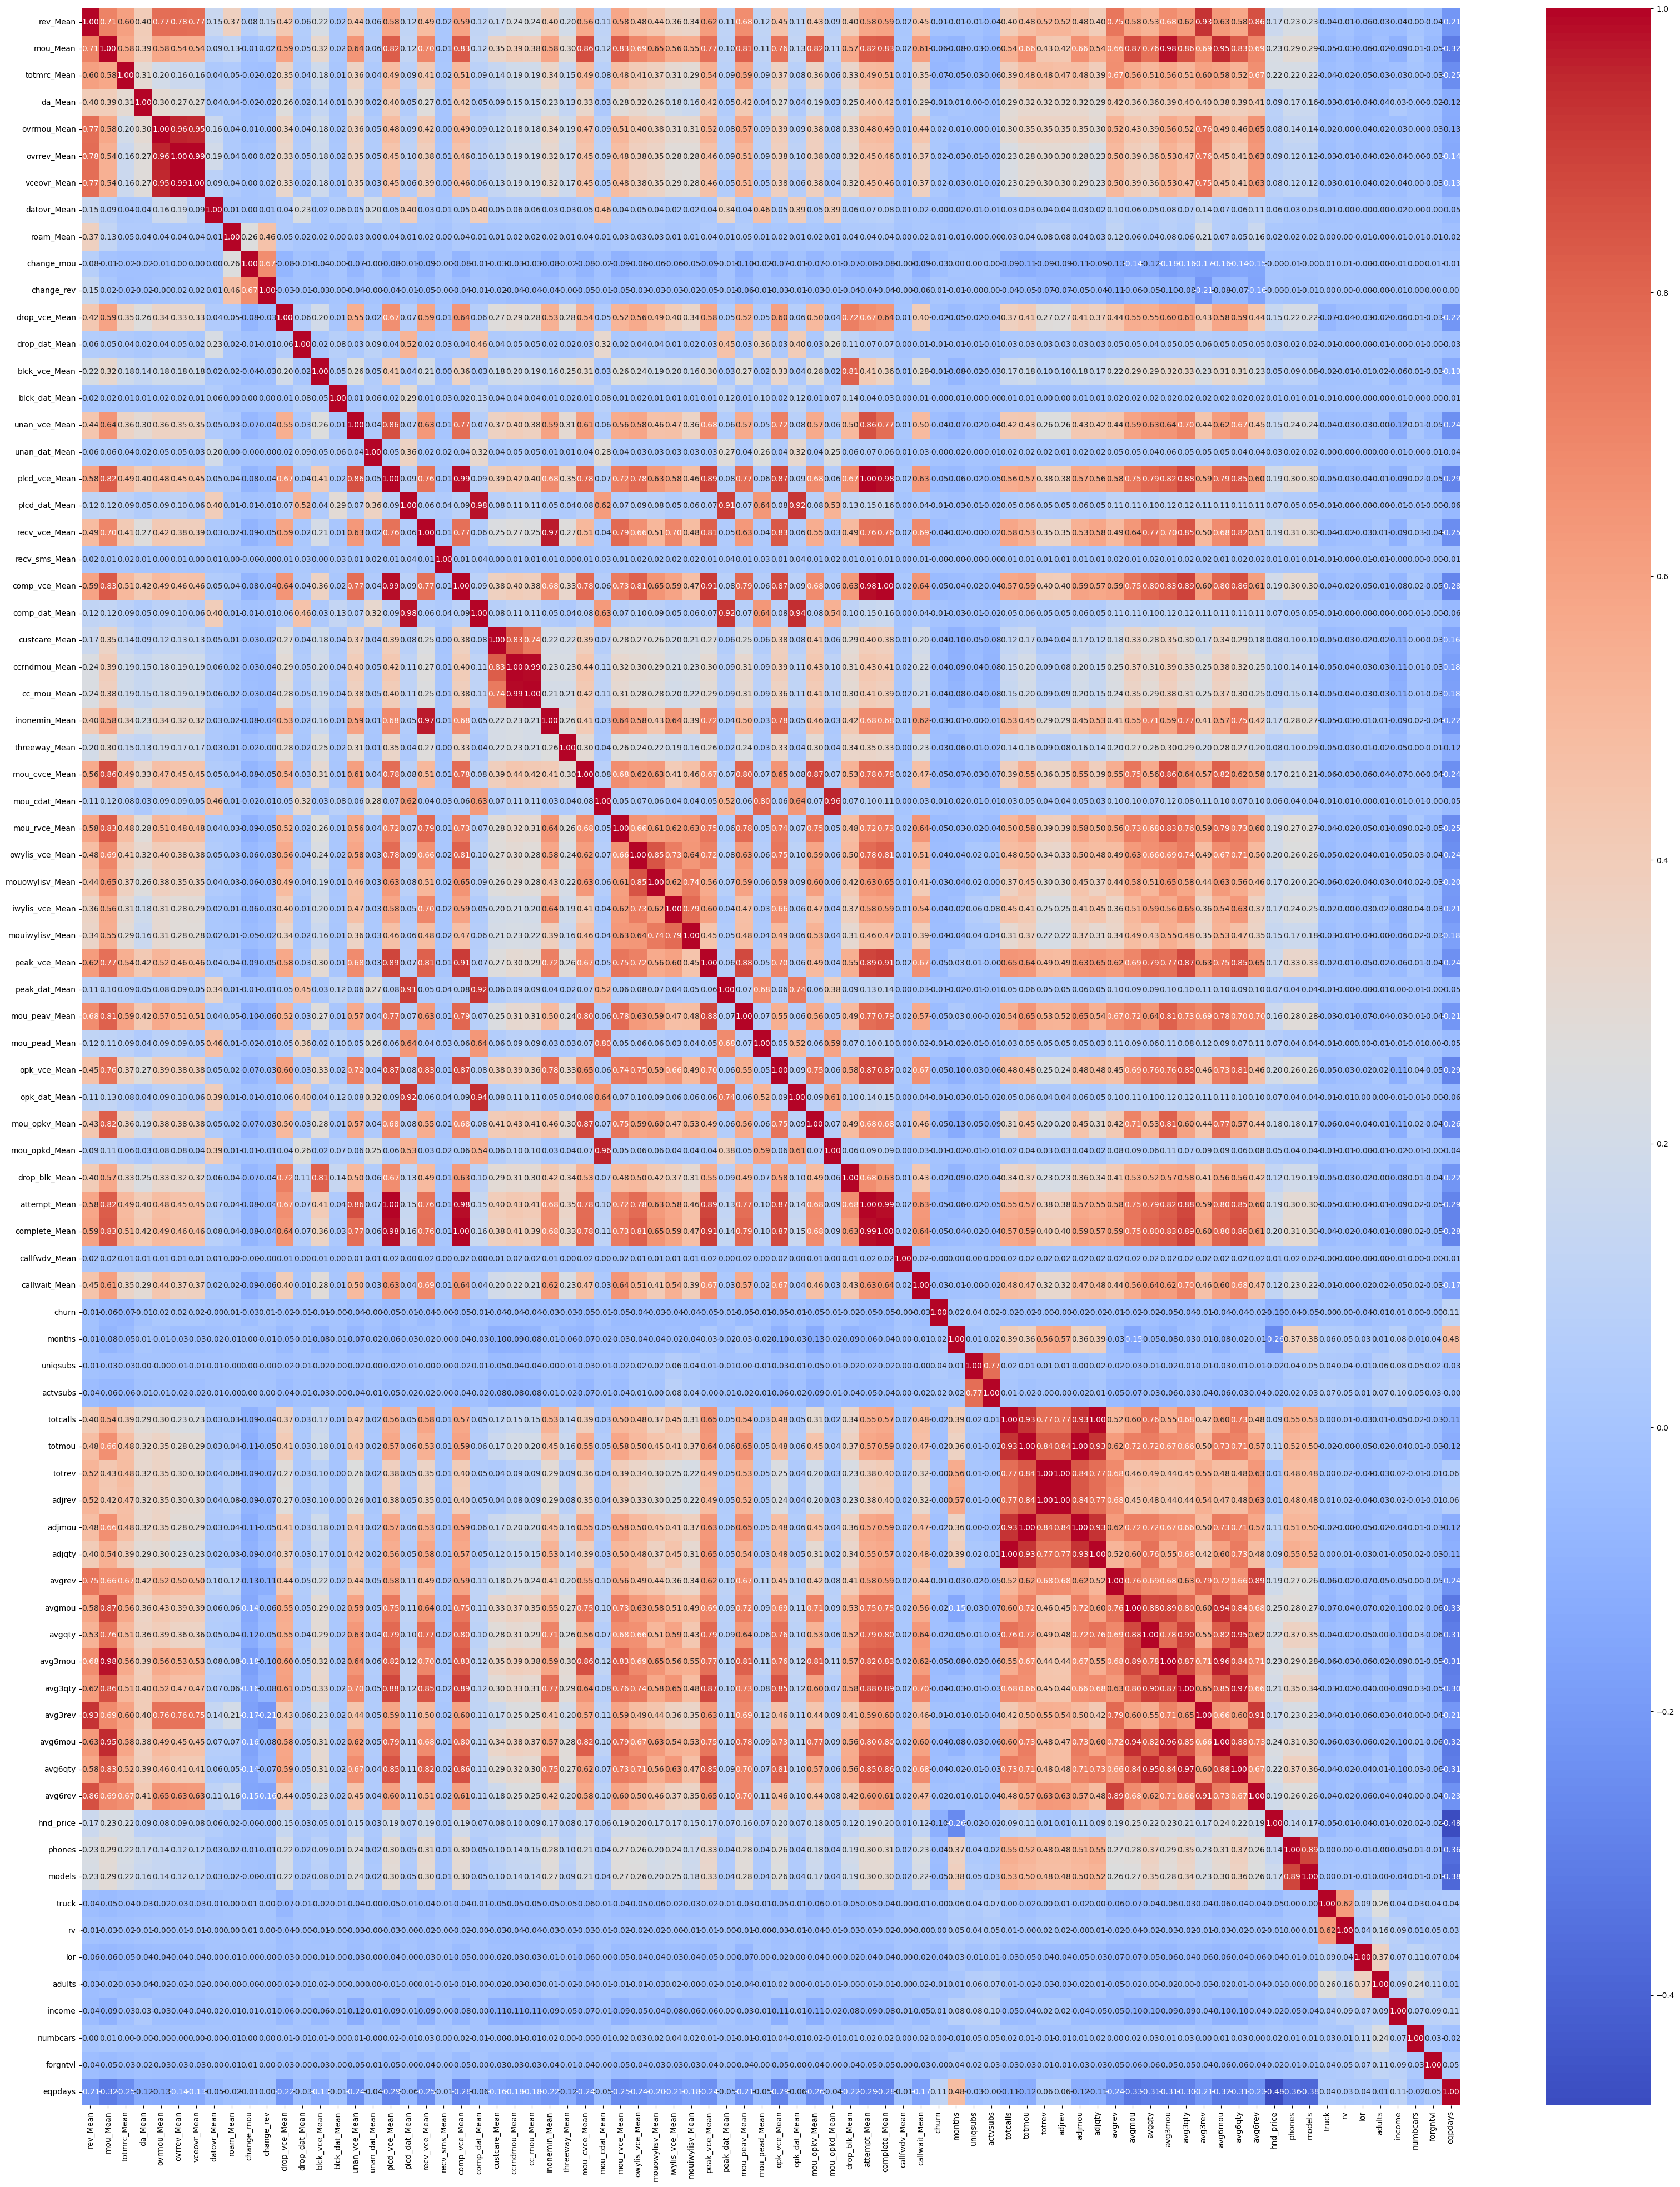

In [85]:
plt.figure(figsize=(40,49))
sns.heatmap(corr_matrix,fmt=".2f",annot=True,cmap="coolwarm")
plt.show()

- We can not see anything from this heatmap because it is very big
- So I will do a mask and unstack for the correlation to present them in good df and get the names of the features

In [86]:
corr_matrix=corr_matrix.abs()

In [87]:
ones_array=np.ones(shape=corr_matrix.shape)
ones_array

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], shape=(78, 78))

In [88]:
below_active_area=np.tril(ones_array,k=-1).astype(bool)
below_active_area

array([[False, False, False, ..., False, False, False],
       [ True, False, False, ..., False, False, False],
       [ True,  True, False, ..., False, False, False],
       ...,
       [ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ...,  True, False, False],
       [ True,  True,  True, ...,  True,  True, False]], shape=(78, 78))

In [89]:
corr_matrix_below_area=corr_matrix.where(below_active_area)
corr_unstack=corr_matrix_below_area.unstack()
corr_unstack=corr_unstack.dropna(axis=0)
corr_unstack

rev_Mean  mou_Mean       0.706029
          totmrc_Mean    0.602148
          da_Mean        0.403806
          ovrmou_Mean    0.772117
          ovrrev_Mean    0.776647
                           ...   
income    forgntvl       0.088237
          eqpdays        0.105680
numbcars  forgntvl       0.025110
          eqpdays        0.019281
forgntvl  eqpdays        0.046153
Length: 3003, dtype: float64

In [90]:
corr_unstack=corr_unstack.sort_values(ascending=False)
corr_unstack

totcalls       adjqty           0.999798
totmou         adjmou           0.999747
totrev         adjrev           0.998492
plcd_vce_Mean  attempt_Mean     0.998398
comp_vce_Mean  complete_Mean    0.997706
                                  ...   
opk_dat_Mean   forgntvl         0.000094
vceovr_Mean    numbcars         0.000074
change_rev     actvsubs         0.000053
recv_sms_Mean  callfwdv_Mean    0.000010
peak_dat_Mean  income           0.000008
Length: 3003, dtype: float64

- Now we can detect there are features has high correlation up to 99%

In [91]:
corr_unstack=corr_unstack.reset_index()

- Now there is good presentation in df

In [92]:
corr_unstack.columns=["First","Second","Ratio"]

In [93]:
corr_unstack

,First,Second,Ratio
0,totcalls,adjqty,0.999798
1,totmou,adjmou,0.999747
2,totrev,adjrev,0.998492
3,plcd_vce_Mean,attempt_Mean,0.998398
4,comp_vce_Mean,complete_Mean,0.997706
...,...,...,...
2998,opk_dat_Mean,forgntvl,0.000094
2999,vceovr_Mean,numbcars,0.000074
3000,change_rev,actvsubs,0.000053
3001,recv_sms_Mean,callfwdv_Mean,0.000010


In [94]:
high_corr=corr_unstack[corr_unstack["Ratio"]>=0.80]
high_corr

,First,Second,Ratio
0,totcalls,adjqty,0.999798
1,totmou,adjmou,0.999747
2,totrev,adjrev,0.998492
3,plcd_vce_Mean,attempt_Mean,0.998398
4,comp_vce_Mean,complete_Mean,0.997706
...,...,...,...
99,comp_vce_Mean,owylis_vce_Mean,0.810337
100,owylis_vce_Mean,complete_Mean,0.809994
101,mou_cvce_Mean,mou_peav_Mean,0.803652
102,complete_Mean,avg6mou,0.803485


- There are most important columns I will use them so I will delet the crosbonding feature for it

In [95]:
important_features_list = [
    'eqpdays',
    'change_mou',
    'change_rev',
    'months',
    'mou_Mean',
    'avgqty',
    'rev_Mean',
    'totrev',
    'totcalls'
]

In [96]:
names_cols_high_corr=list(high_corr["Second"].unique())
names_cols_high_corr

['adjqty',
 'adjmou',
 'adjrev',
 'attempt_Mean',
 'complete_Mean',
 'vceovr_Mean',
 'cc_mou_Mean',
 'comp_vce_Mean',
 'comp_dat_Mean',
 'avg3mou',
 'avg6qty',
 'inonemin_Mean',
 'avg6mou',
 'mou_opkd_Mean',
 'ovrrev_Mean',
 'opk_dat_Mean',
 'avg3rev',
 'totmou',
 'peak_dat_Mean',
 'avg6rev',
 'peak_vce_Mean',
 'avg3qty',
 'models',
 'avgqty',
 'mou_peav_Mean',
 'opk_vce_Mean',
 'mou_opkv_Mean',
 'avgmou',
 'mou_cvce_Mean',
 'plcd_vce_Mean',
 'mouowylisv_Mean',
 'totrev',
 'mou_rvce_Mean',
 'ccrndmou_Mean',
 'drop_blk_Mean',
 'owylis_vce_Mean']

In [97]:
one_full_data_phase=full_data.copy()

In [98]:

for x in names_cols_high_corr:
    if x not in important_features_list:
        one_full_data_phase.drop(x,axis=1,inplace=True)
        

In [99]:
one_full_data_phase.shape

(100000, 65)

- make sure again if there is not high corr

In [100]:
num_cols_corr_phase1=one_full_data_phase.select_dtypes(include="number").columns

In [101]:
corr_matrix_phase1=one_full_data_phase.loc[:,num_cols_corr_phase1].corr()
corr_matrix_phase1=corr_matrix_phase1.abs()
ones_array_phase1=np.ones(corr_matrix_phase1.shape)
mask_phase1=np.tril(ones_array_phase1,k=-1).astype(bool)
corr_matrix_phase1=corr_matrix_phase1.where(mask_phase1)
corr_unstack_phase1=corr_matrix_phase1.unstack()
corr_unstack_phase1=corr_unstack_phase1.dropna(axis=0)
corr_unstack_phase1.sort_values(ascending=False)


mou_cdat_Mean    mou_pead_Mean      0.797174
iwylis_vce_Mean  mouiwylisv_Mean    0.785465
uniqsubs         actvsubs           0.774229
recv_vce_Mean    avgqty             0.773506
rev_Mean         ovrmou_Mean        0.772117
                                      ...   
ovrmou_Mean      uniqsubs           0.000207
change_rev       numbcars           0.000202
change_mou       uniqsubs           0.000185
change_rev       actvsubs           0.000053
recv_sms_Mean    callfwdv_Mean      0.000010
Length: 946, dtype: float64

- it is done now

---

- let's see the nan values of the data

In [102]:
nan_phase_one=one_full_data_phase.isna().sum().sort_values(ascending=False)
nan_phase_one[nan_phase_one>0]

numbcars            49366
dwllsize            38308
HHstatin            37923
ownrent             33706
dwlltype            31909
lor                 30190
income              25436
adults              23019
infobase            22079
hnd_webcap          10189
prizm_social_one     7388
kid6_10              1732
ethnic               1732
marital              1732
rv                   1732
truck                1732
forgntvl             1732
kid0_2               1732
kid3_5               1732
kid16_17             1732
creditcd             1732
kid11_15             1732
change_mou            891
change_rev            891
hnd_price             847
rev_Mean              357
ovrmou_Mean           357
mou_Mean              357
totmrc_Mean           357
roam_Mean             357
da_Mean               357
datovr_Mean           357
area                   40
phones                  1
dualband                1
refurb_new              1
eqpdays                 1
dtype: int64

- Delete high nan values features

In [103]:
two_full_data_phase=one_full_data_phase.copy()

In [104]:
two_full_data_phase["HHstatin"].unique()

<StringArray>
['C', 'I', nan, 'B', 'A', 'G', 'H']
Length: 7, dtype: str

In [105]:
two_full_data_phase.drop(["numbcars","ownrent","infobase","dwllsize","HHstatin","dwlltype"],axis=1,inplace=True)

In [106]:
two_full_data_phase.shape

(100000, 59)

## Solve Nan Values

In [107]:
two_full_data_phase["income"]=two_full_data_phase["income"].fillna(-1)
two_full_data_phase["income"].isna().sum()

np.int64(0)

In [108]:
two_full_data_phase["hnd_webcap"].value_counts()

hnd_webcap
WCMB    75733
WC      13843
UNKW      235
Name: count, dtype: int64

In [109]:
two_full_data_phase['hnd_webcap'] = two_full_data_phase['hnd_webcap'].fillna('Missing')

In [110]:
two_full_data_phase['lor'] = two_full_data_phase['lor'].fillna(two_full_data_phase['lor'].median())

In [111]:
two_full_data_phase['adults'] = two_full_data_phase['adults'].fillna(two_full_data_phase['adults'].median())

In [112]:
two_full_data_phase.shape

(100000, 59)

- If the columns which has more than 30000 nan values are not important I will delete it

---

# intial model

In [113]:
cat_cols_phase2=list(two_full_data_phase.select_dtypes(include="object"))
num_cols_phase2=two_full_data_phase.select_dtypes(include="number")

C:\Users\Access\AppData\Local\Temp\ipykernel_15824\2408055169.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_phase2=list(two_full_data_phase.select_dtypes(include="object"))


In [114]:
for x in cat_cols_phase2:
    print(x)
    print(len(list(two_full_data_phase[x].unique())))

new_cell
3
crclscod
54
asl_flag
2
prizm_social_one
6
area
20
dualband
5
refurb_new
3
hnd_webcap
4
marital
6
ethnic
18
kid0_2
3
kid3_5
3
kid6_10
3
kid11_15
3
kid16_17
3
creditcd
3


In [115]:
two_full_data_phase.drop(["crclscod","area","ethnic"],axis=1,inplace=True)

In [116]:
cat_cols_phase2=list(two_full_data_phase.select_dtypes(include="object"))


C:\Users\Access\AppData\Local\Temp\ipykernel_15824\3170581592.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_phase2=list(two_full_data_phase.select_dtypes(include="object"))


In [117]:
from sklearn.model_selection import StratifiedShuffleSplit

In [ ]:
splitter_phase2=StratifiedShuffleSplit(n_splits=1,test_size=0.2)
for train_index , test_index in splitter_phase2.split(two_full_data_phase,two_full_data_phase["churn"]):
    strat_train_phase2=two_full_data_phase.loc[train_index]
    strat_test_phase2=two_full_data_phase.loc[test_index]

In [ ]:
strat_train_x_phase2=strat_train_phase2.drop("churn",axis=1)
strat_train_y_phase2=strat_train_phase2["churn"]

strat_test_x_phase2=strat_test_phase2.drop("churn",axis=1)
strat_test_y_phase2=strat_test_phase2["churn"]

In [ ]:
from xgboost import XGBClassifier

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
for col in cat_cols_phase2:
    if col in strat_train_x_phase2.columns:
        strat_train_x_phase2[col] = strat_train_x_phase2[col].astype('category')
    if col in strat_test_x_phase2.columns:
        strat_test_x_phase2[col] = strat_test_x_phase2[col].astype('category')

In [ ]:
intial_model=XGBClassifier(
    n_estimators=1300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3.5,
    random_state=42,
    enable_categorical=True
)

intial_model.fit(
    strat_train_x_phase2,
    strat_train_y_phase2,
    verbose=False,
    
)


y_pred=intial_model.predict(strat_test_x_phase2)
print(classification_report(strat_test_y_phase2,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.18      0.29     10088
           1       0.53      0.95      0.68      9912

    accuracy                           0.56     20000
   macro avg       0.65      0.56      0.49     20000
weighted avg       0.65      0.56      0.49     20000



In [ ]:
importance_feature=intial_model.feature_importances_
importance_feature

array([0.01660037, 0.02479887, 0.02338229, 0.01406116, 0.02001068,
       0.01392345, 0.01397259, 0.02285607, 0.01855739, 0.01631886,
       0.01135264, 0.01426639, 0.01397595, 0.01502874, 0.01288257,
       0.0127184 , 0.01600558, 0.01064325, 0.01551046, 0.01414381,
       0.01505542, 0.01582111, 0.01652861, 0.01440063, 0.01171286,
       0.01490391, 0.04230391, 0.02713839, 0.01762305, 0.01350269,
       0.03322514, 0.01640321, 0.01548919, 0.01792874, 0.0198639 ,
       0.01530082, 0.01650077, 0.04228909, 0.02609411, 0.01574482,
       0.02478606, 0.01436854, 0.01483088, 0.01971356, 0.01647593,
       0.01446752, 0.01677463, 0.01444407, 0.01539577, 0.01461265,
       0.01568832, 0.01546583, 0.01574488, 0.02104723, 0.03734415],
      dtype=float32)

In [ ]:
type(importance_feature)


numpy.ndarray

In [ ]:
df_importance_feature=pd.DataFrame(
    {
        "Feature":strat_train_x_phase2.columns,
        "Importance":importance_feature
    }
).sort_values(by="Importance",ascending=False)
print(df_importance_feature.loc[:])

             Feature  Importance
26            months    0.042304
37        refurb_new    0.042289
54           eqpdays    0.037344
30          asl_flag    0.033225
27          uniqsubs    0.027138
38         hnd_price    0.026094
1           mou_Mean    0.024799
40        hnd_webcap    0.024786
2        totmrc_Mean    0.023382
7         change_mou    0.022856
53          creditcd    0.021047
4        ovrmou_Mean    0.020011
34            avgqty    0.019864
43               lor    0.019714
8         change_rev    0.018557
33            avgrev    0.017929
28          actvsubs    0.017623
46            income    0.016775
0           rev_Mean    0.016600
22   mouiwylisv_Mean    0.016529
36          dualband    0.016501
44           marital    0.016476
31          totcalls    0.016403
9      drop_vce_Mean    0.016319
16     recv_vce_Mean    0.016006
21   iwylis_vce_Mean    0.015821
52          kid16_17    0.015745
39            phones    0.015745
50           kid6_10    0.015688
18     cus

C:\Users\Access\AppData\Local\Temp\ipykernel_6020\1782573353.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=df_importance_feature["Feature"].head(20),x=df_importance_feature["Importance"].head(20),palette="viridis")


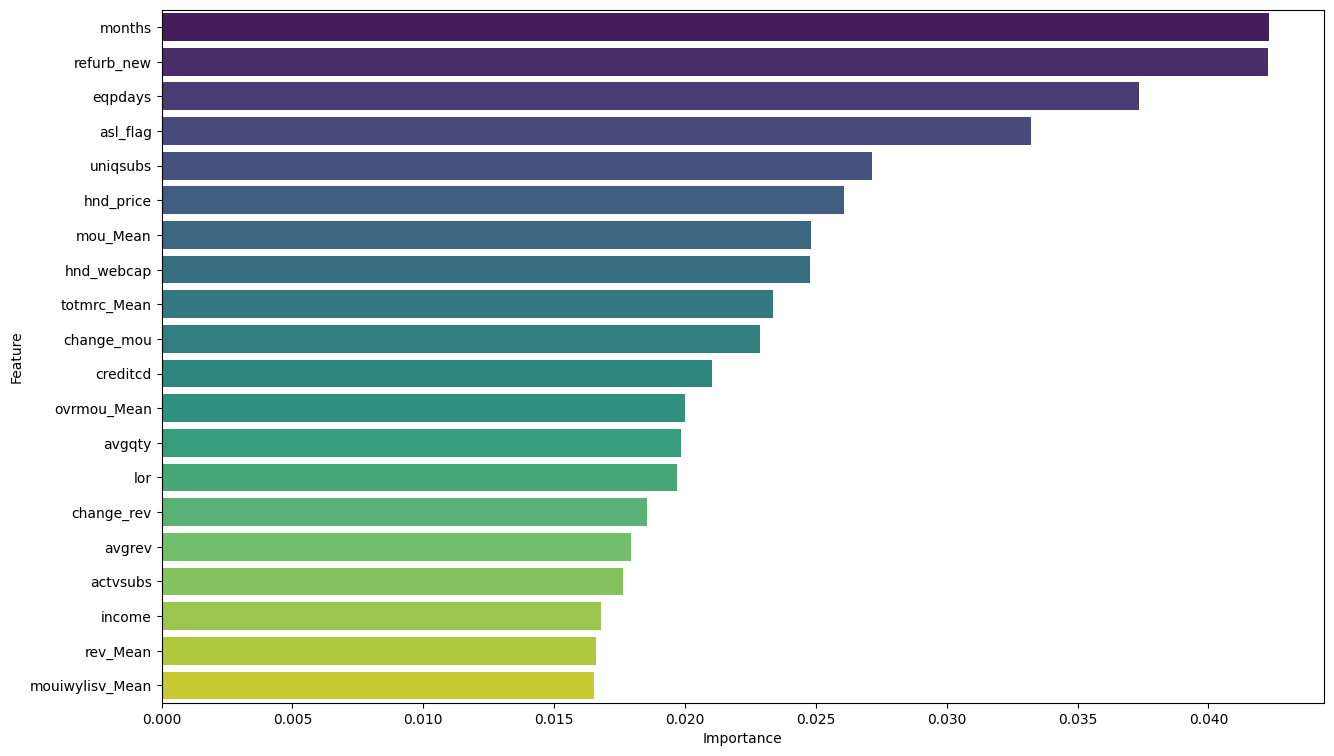

In [ ]:
plt.figure(figsize=(15,9))
sns.barplot(y=df_importance_feature["Feature"].head(20),x=df_importance_feature["Importance"].head(20),palette="viridis")
plt.show()

In [ ]:
df_importance_feature.head(30).reset_index(drop=True)

,Feature,Importance
0,months,0.042304
1,refurb_new,0.042289
2,eqpdays,0.037344
3,asl_flag,0.033225
4,uniqsubs,0.027138
5,hnd_price,0.026094
6,mou_Mean,0.024799
7,hnd_webcap,0.024786
8,totmrc_Mean,0.023382
9,change_mou,0.022856


In [ ]:
most_importance=list(df_importance_feature.head(24)["Feature"])
most_importance

['months',
 'refurb_new',
 'eqpdays',
 'asl_flag',
 'uniqsubs',
 'hnd_price',
 'mou_Mean',
 'hnd_webcap',
 'totmrc_Mean',
 'change_mou',
 'creditcd',
 'ovrmou_Mean',
 'avgqty',
 'lor',
 'change_rev',
 'avgrev',
 'actvsubs',
 'income',
 'rev_Mean',
 'mouiwylisv_Mean',
 'dualband',
 'marital',
 'totcalls',
 'drop_vce_Mean']

In [ ]:
most_importance.append("totrev")

In [ ]:
most_importance

['months',
 'refurb_new',
 'eqpdays',
 'asl_flag',
 'uniqsubs',
 'hnd_price',
 'mou_Mean',
 'hnd_webcap',
 'totmrc_Mean',
 'change_mou',
 'creditcd',
 'ovrmou_Mean',
 'avgqty',
 'lor',
 'change_rev',
 'avgrev',
 'actvsubs',
 'income',
 'rev_Mean',
 'mouiwylisv_Mean',
 'dualband',
 'marital',
 'totcalls',
 'drop_vce_Mean',
 'totrev']

In [709]:
len(most_importance)

25

# Now we have the most important features

In [118]:
# I will do list for these columns because if i re do the file again maybe the columns change because i did not set random state for the intial model
most_importance=['months',
 'refurb_new',
 'eqpdays',
 'asl_flag',
 'uniqsubs',
 'hnd_price',
 'mou_Mean',
 'hnd_webcap',
 'totmrc_Mean',
 'change_mou',
 'creditcd',
 'ovrmou_Mean',
 'avgqty',
 'lor',
 'change_rev',
 'avgrev',
 'actvsubs',
 'income',
 'rev_Mean',
 'mouiwylisv_Mean',
 'dualband',
 'marital',
 'totcalls',
 'drop_vce_Mean',
 'totrev']

In [119]:
three_full_data_phase=two_full_data_phase.copy()

In [120]:
most_importance.append("churn")

In [121]:
three_full_data_phase=three_full_data_phase.loc[:,most_importance]
three_full_data_phase.shape

(100000, 26)

In [122]:
three_full_data_phase.columns

Index(['months', 'refurb_new', 'eqpdays', 'asl_flag', 'uniqsubs', 'hnd_price',
       'mou_Mean', 'hnd_webcap', 'totmrc_Mean', 'change_mou', 'creditcd',
       'ovrmou_Mean', 'avgqty', 'lor', 'change_rev', 'avgrev', 'actvsubs',
       'income', 'rev_Mean', 'mouiwylisv_Mean', 'dualband', 'marital',
       'totcalls', 'drop_vce_Mean', 'totrev', 'churn'],
      dtype='str')

In [123]:
final_data=three_full_data_phase.copy()

# Start EDA

c:\Users\Access\Desktop\final_gci\.venv\Lib\site-packages\seaborn\distributions.py:474: RuntimeWarning: invalid value encountered in subtract
  edges = res[orient].to_numpy() - widths / 2


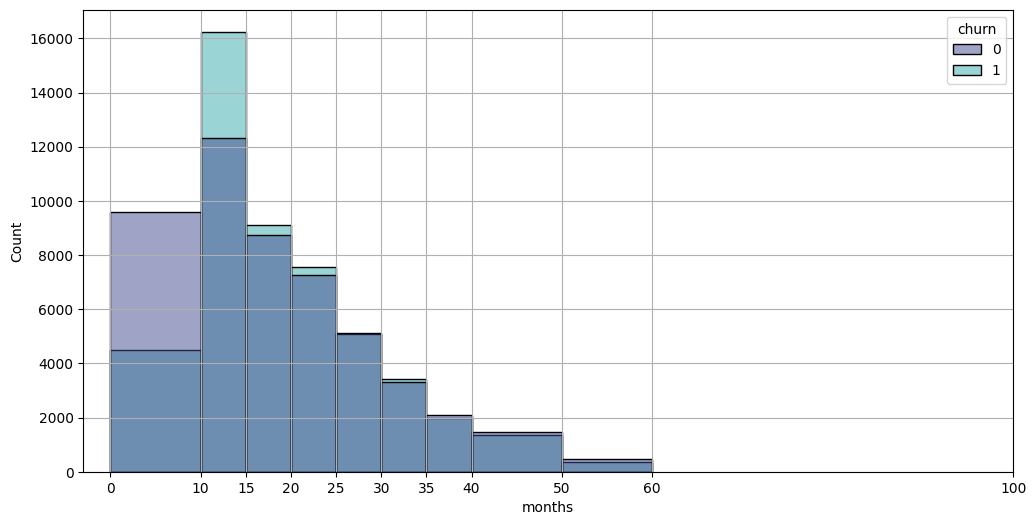

In [44]:
plt.figure(figsize=(12,6))
sns.histplot(data=final_data,x="months",bins=[0,10,15,20,25,30,35,40,50,60,np.inf],hue="churn",palette="mako")
plt.xticks([0,10,15,20,25,30,35,40,50,60,100])
plt.grid()
plt.show()
# there are in the customers after first of 10 months because the people leave more than stay

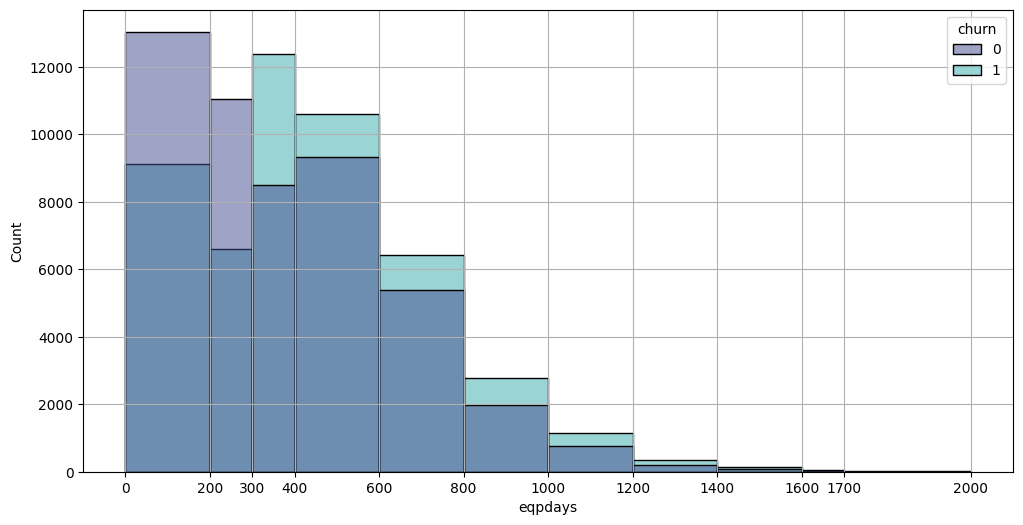

In [716]:
plt.figure(figsize=(12,6))
sns.histplot(data=final_data,x="eqpdays",bins=[0,200,300,400,600,800,1000,1200,1400,1600,1700,2000],hue="churn",palette="mako")
plt.xticks([0,200,300,400,600,800,1000,1200,1400,1600,1700,2000])
plt.grid()
plt.show()
# after first 300 days or let's say after one year of using the phone they leave

In [717]:
final_data["rev_Mean"].max()

np.float64(3843.2625)

In [718]:
bins=list(np.arange(0,501,100))
bins.append(np.inf)

c:\Users\Access\Desktop\final_gci\.venv\Lib\site-packages\seaborn\distributions.py:474: RuntimeWarning: invalid value encountered in subtract
  edges = res[orient].to_numpy() - widths / 2


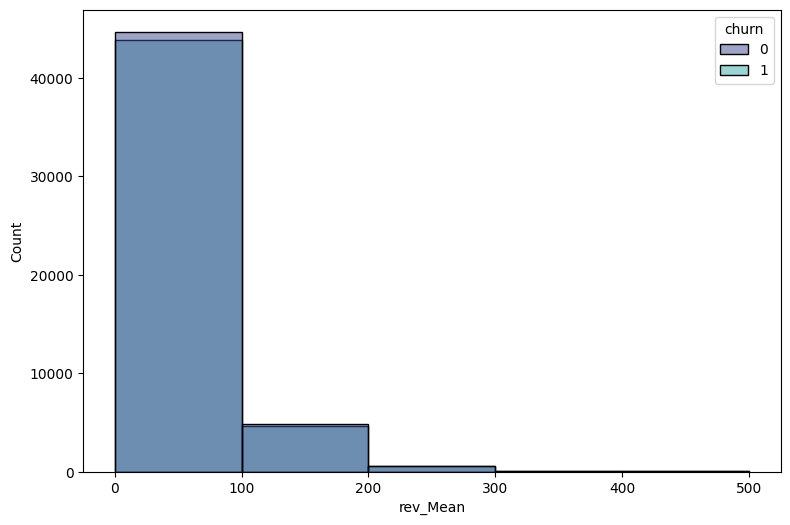

In [719]:
plt.figure(figsize=(9,6))
sns.histplot(data=final_data,x="rev_Mean",bins=bins,hue="churn",palette="mako")
plt.show()

In [720]:
final_data["change_rev"].min()

np.float64(-1107.74)

In [721]:
bins=list(np.arange(-200,201
                    ,20))


In [722]:
bins

[np.int64(-200),
 np.int64(-180),
 np.int64(-160),
 np.int64(-140),
 np.int64(-120),
 np.int64(-100),
 np.int64(-80),
 np.int64(-60),
 np.int64(-40),
 np.int64(-20),
 np.int64(0),
 np.int64(20),
 np.int64(40),
 np.int64(60),
 np.int64(80),
 np.int64(100),
 np.int64(120),
 np.int64(140),
 np.int64(160),
 np.int64(180),
 np.int64(200)]

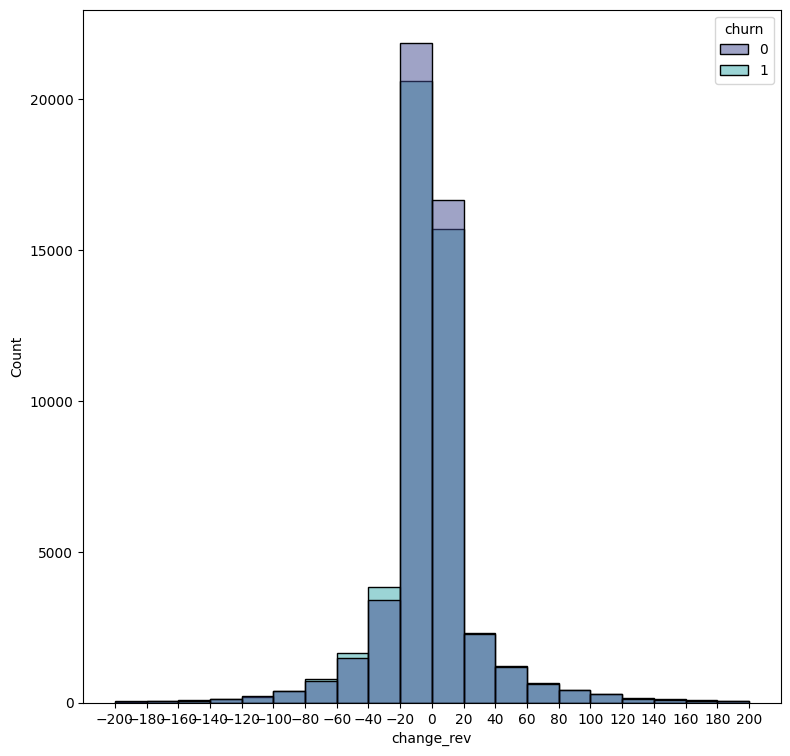

In [723]:
plt.figure(figsize=(9,9))
sns.histplot(data=final_data,x="change_rev",hue="churn",palette="mako",bins=bins)
plt.xticks(bins,)
plt.show()

In [724]:
bins=list(np.arange(0,151,20))
bins.append(300)

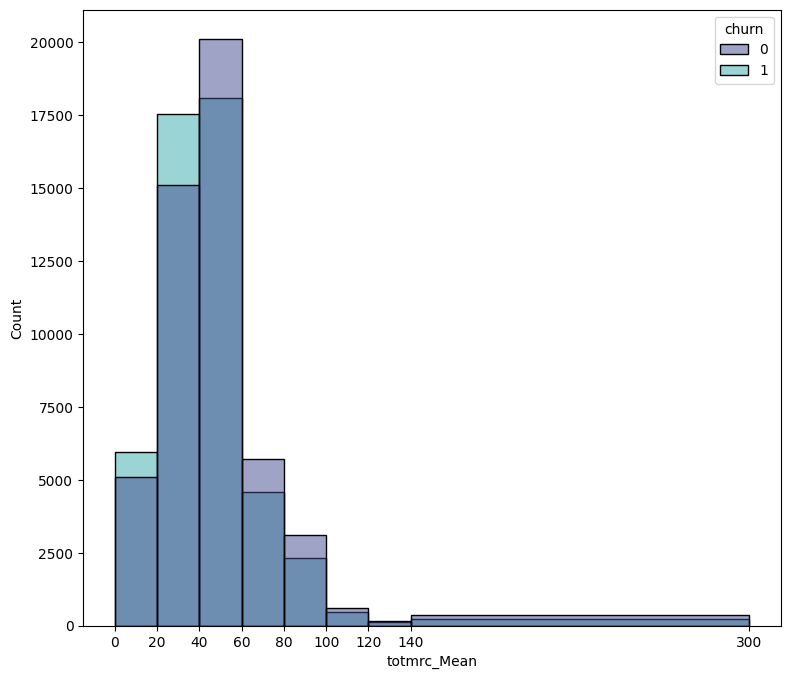

In [725]:
plt.figure(figsize=(9,8))
sns.histplot(data=final_data,x="totmrc_Mean",hue="churn",palette="mako",bins=bins)
plt.xticks(bins)
plt.show()

In [726]:
bins=list(np.arange(0,1001,100))

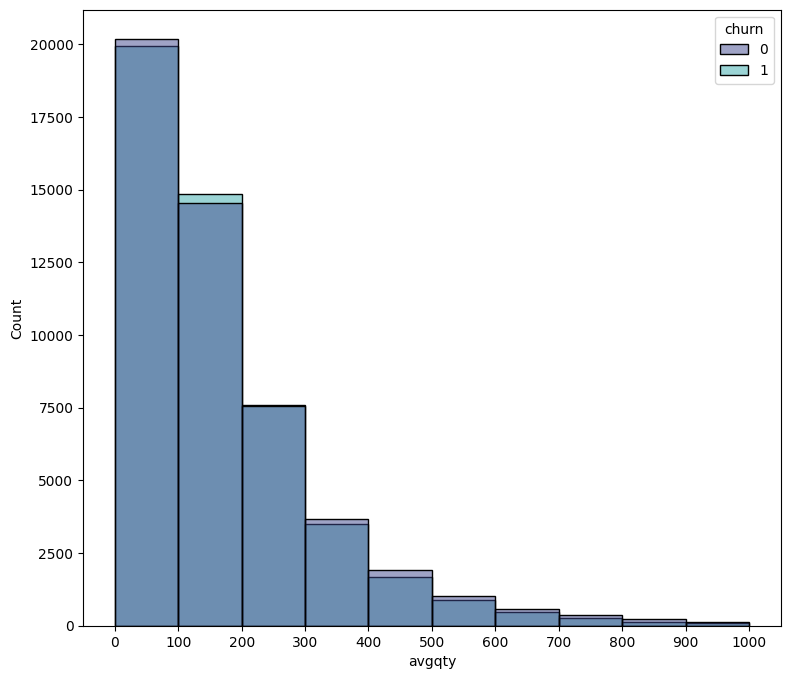

In [727]:
plt.figure(figsize=(9,8))
sns.histplot(data=final_data,x="avgqty",hue="churn",palette="mako",bins=bins)
plt.xticks(bins)
plt.show()

In [728]:
bins=np.arange(0,1001,50)

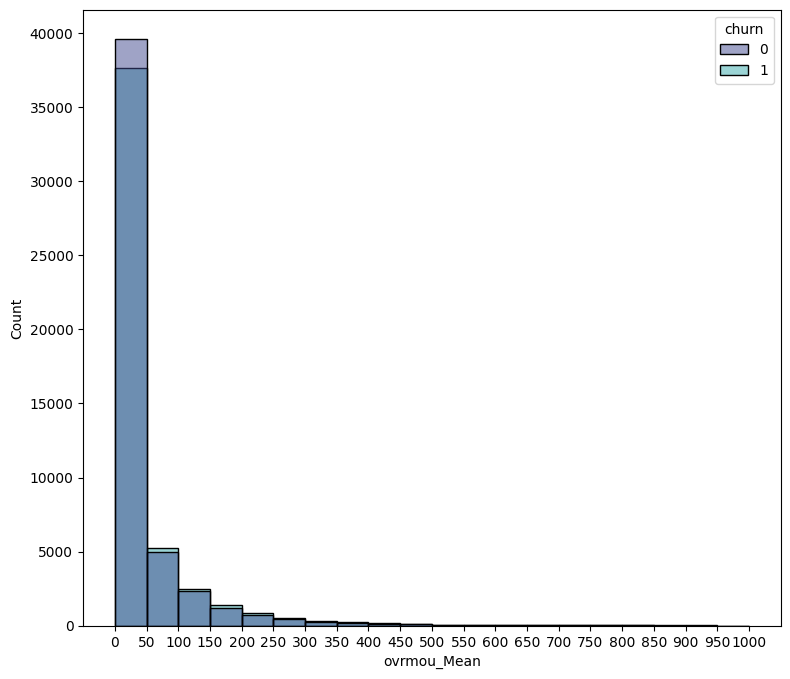

In [729]:
plt.figure(figsize=(9,8))
sns.histplot(data=final_data,x="ovrmou_Mean",hue="churn",palette="mako",bins=bins)
plt.xticks(bins)
plt.show()

In [730]:
bins=np.arange(0,2000,100)

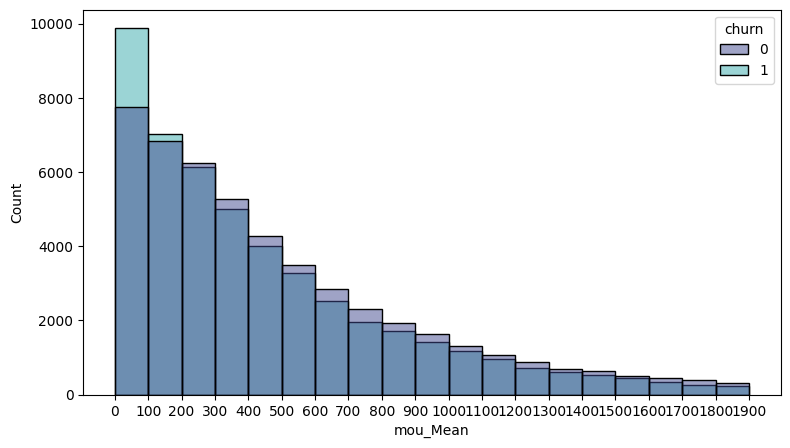

In [731]:
plt.figure(figsize=(9,5))
sns.histplot(data=final_data,x="mou_Mean",palette="mako",hue="churn",bins=bins)
plt.xticks(bins)
plt.show()
# small subscribtions are weak

In [732]:
bins=np.arange(0,4001,250)

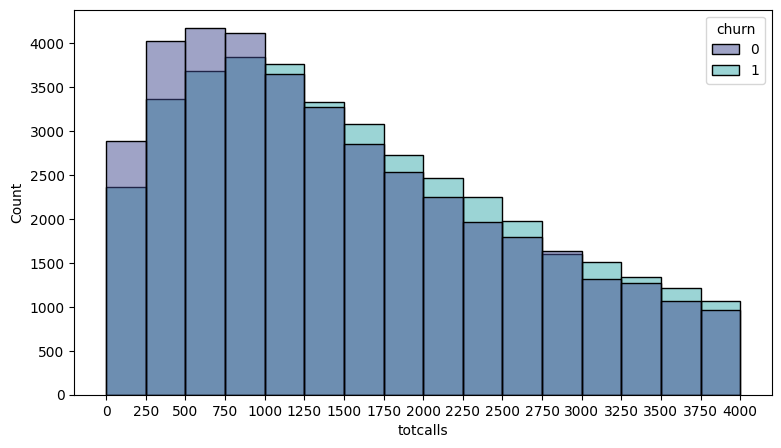

In [733]:
plt.figure(figsize=(9,5))
sns.histplot(data=final_data,x="totcalls",palette="mako",hue="churn",bins=bins)
plt.xticks(bins)
plt.show()
# people which talks for about 1500 calls are stayed

In [734]:
bins=np.arange(0,1000,50)

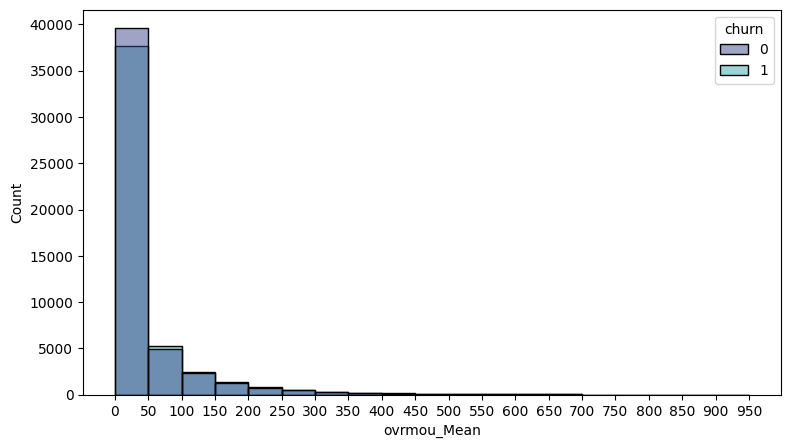

In [735]:
plt.figure(figsize=(9,5))
sns.histplot(data=final_data,hue="churn",x="ovrmou_Mean",palette="mako",bins=bins)
plt.xticks(bins)
plt.show()

In [736]:
final_data["lor"].max()

np.float64(15.0)

In [737]:
bins=np.arange(0,16)

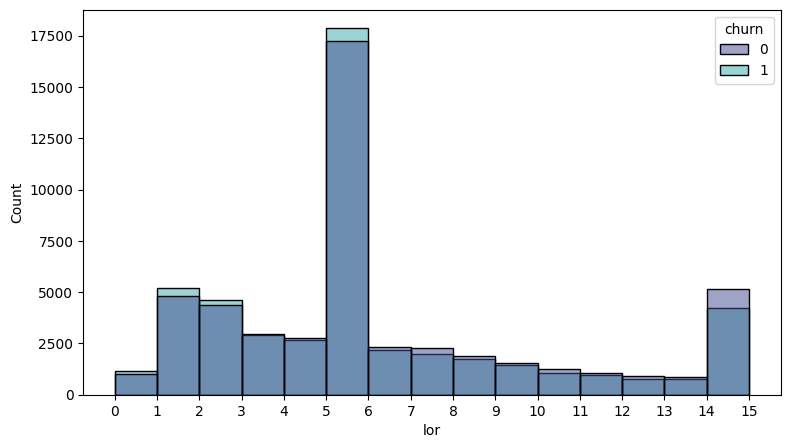

In [738]:
plt.figure(figsize=(9,5))
sns.histplot(data=final_data,hue="churn",x="lor",palette="mako",bins=bins)
plt.xticks(bins)
plt.show()

# Now VS Relations

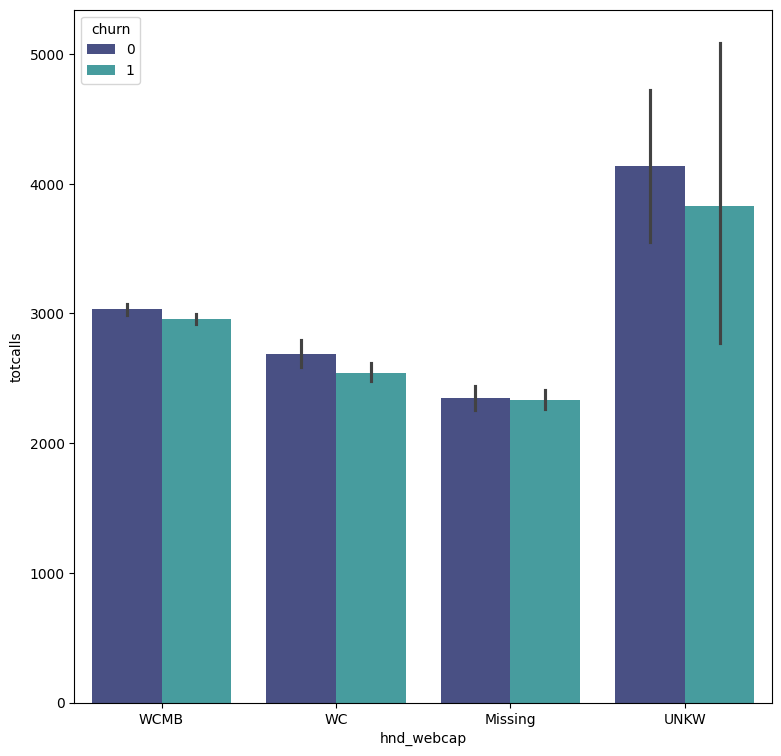

In [739]:
plt.figure(figsize=(9,9))
sns.barplot(data=final_data,x="hnd_webcap",hue="churn",y="totcalls",palette="mako")
plt.show()

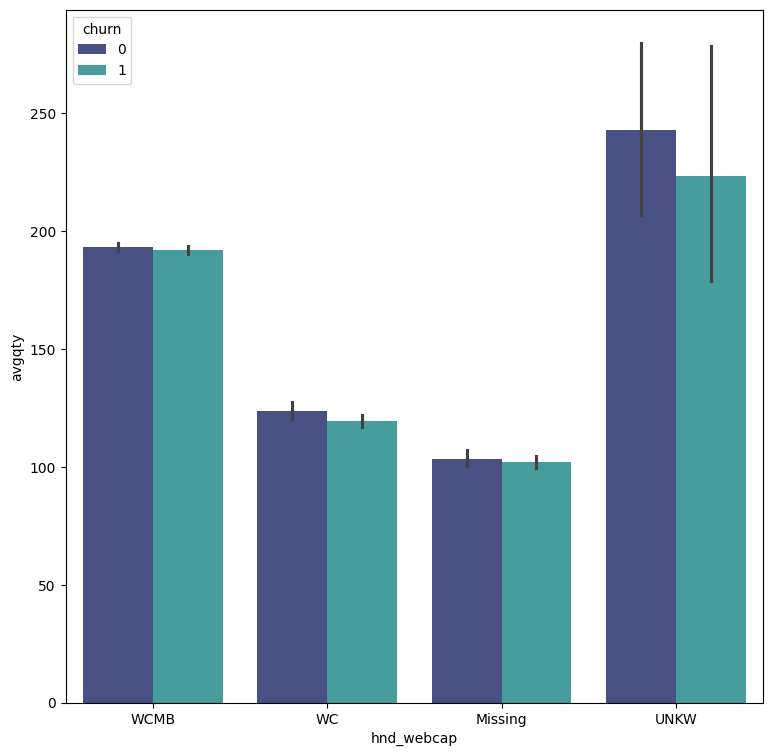

In [740]:
plt.figure(figsize=(9,9))
sns.barplot(data=final_data,x="hnd_webcap",hue="churn",y="avgqty",palette="mako")
plt.show()

In [741]:
cat_eqpdays=pd.cut(
    final_data["eqpdays"],
    bins=[0,300,600,900,np.inf],
    labels=["year_1","year_2","year_3","old"],
    include_lowest=True
)
cat_eqpdays

0        year_2
1        year_1
2           old
3           old
4        year_2
          ...  
99995    year_3
99996    year_3
99997    year_2
99998    year_1
99999    year_1
Name: eqpdays, Length: 100000, dtype: category
Categories (4, str): ['year_1' < 'year_2' < 'year_3' < 'old']

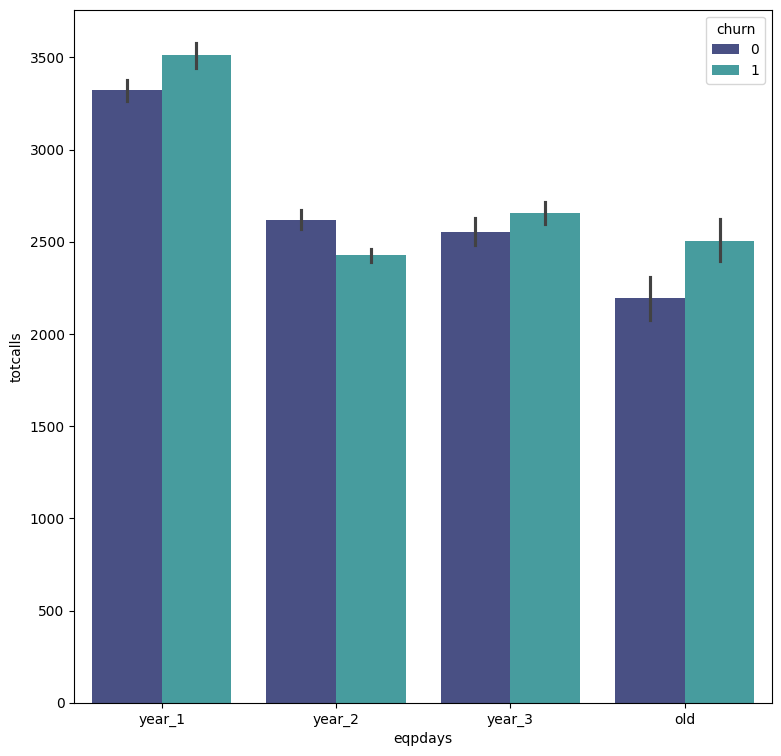

In [742]:
plt.figure(figsize=(9,9))
sns.barplot(data=final_data,x=cat_eqpdays,hue="churn",y="totcalls",palette="mako")
plt.show()

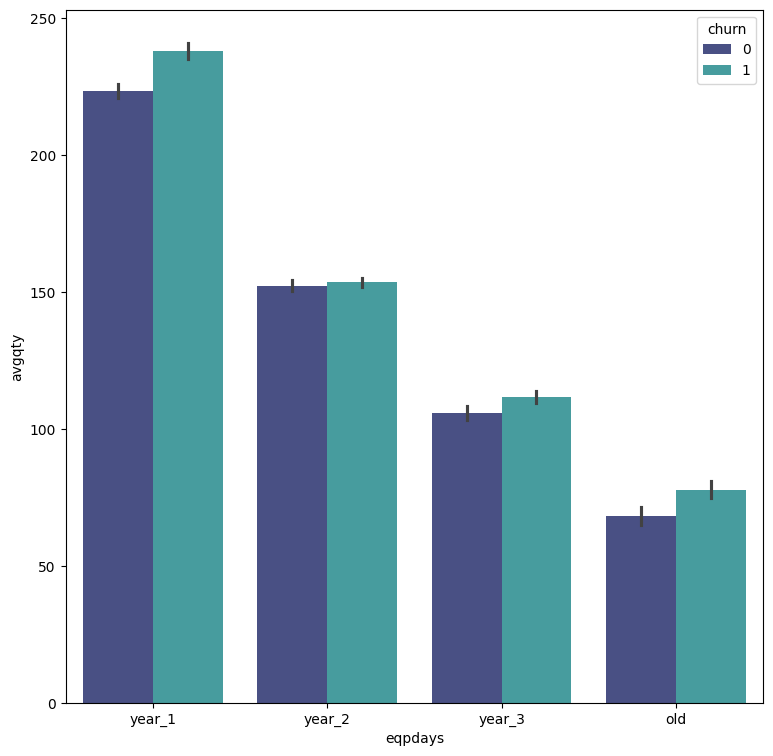

In [743]:
plt.figure(figsize=(9,9))
sns.barplot(data=final_data,x=cat_eqpdays,hue="churn",y="avgqty",palette="mako")
plt.show()
# most important

In [744]:
cat_months=pd.cut(
    final_data["months"],
    bins=[0,10,20,40,np.inf],
    labels=["0-10","10-20","20-40","40--"],
    include_lowest=True
)
cat_months

0         40--
1         40--
2         40--
3         40--
4         40--
         ...  
99995    20-40
99996    20-40
99997    20-40
99998    20-40
99999    20-40
Name: months, Length: 100000, dtype: category
Categories (4, str): ['0-10' < '10-20' < '20-40' < '40--']

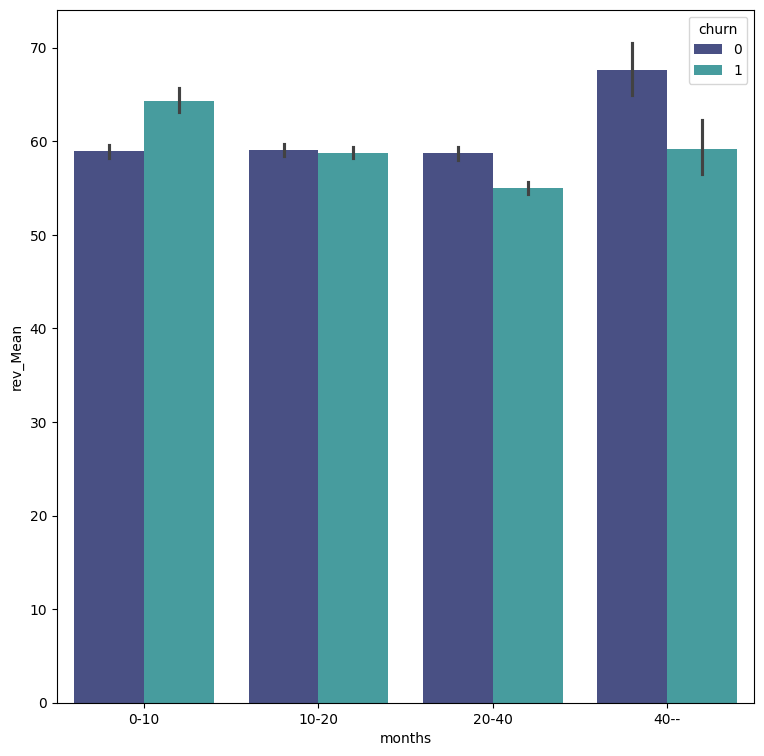

In [745]:
plt.figure(figsize=(9,9))
sns.barplot(data=final_data,x=cat_months,hue="churn",y="rev_Mean",palette="mako")
plt.show()

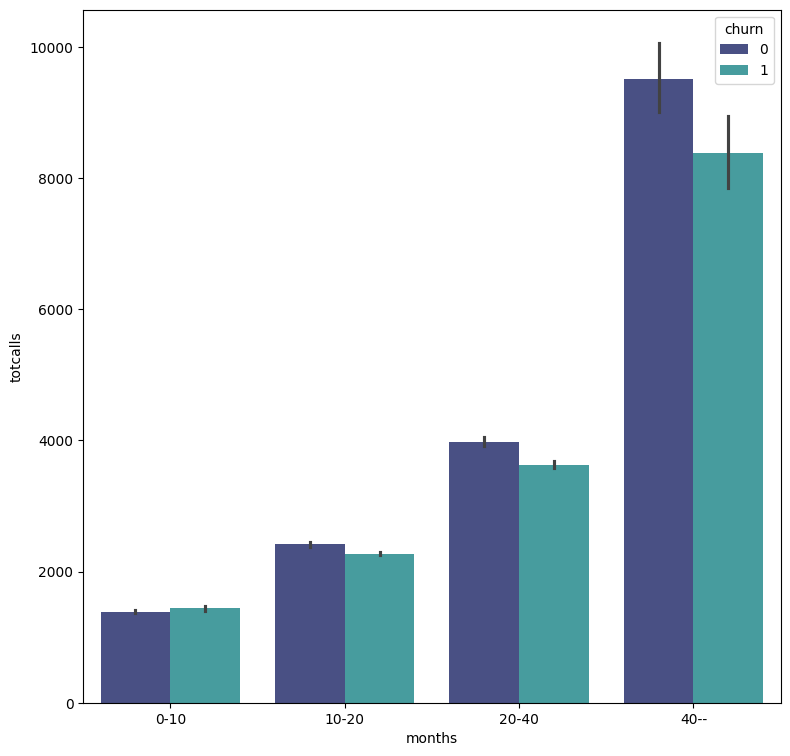

In [746]:
plt.figure(figsize=(9,9))
sns.barplot(data=final_data,x=cat_months,hue="churn",y="totcalls",palette="mako")
plt.show()

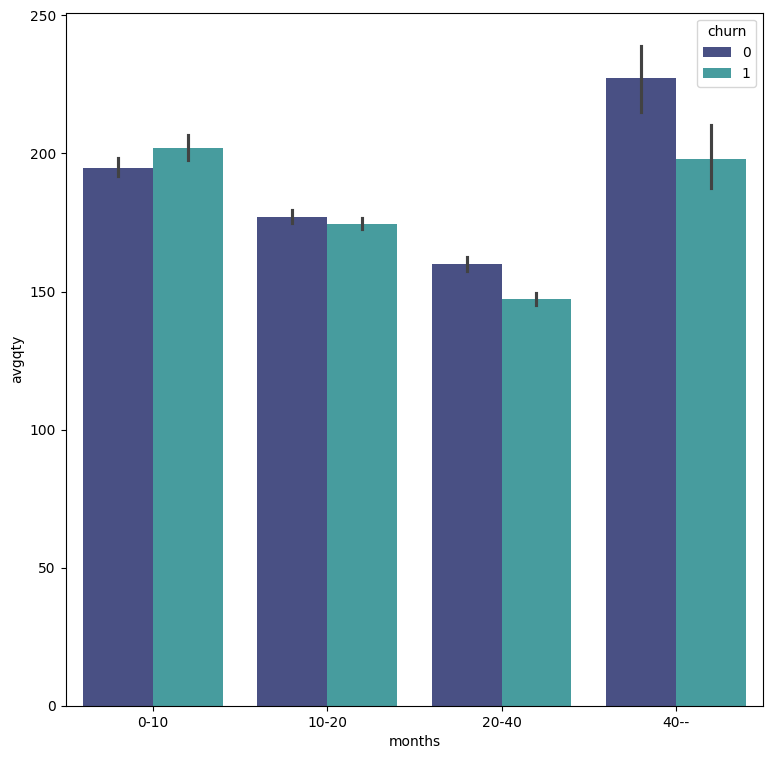

In [747]:
plt.figure(figsize=(9,9))
sns.barplot(data=final_data,x=cat_months,hue="churn",y="avgqty",palette="mako")
plt.show()

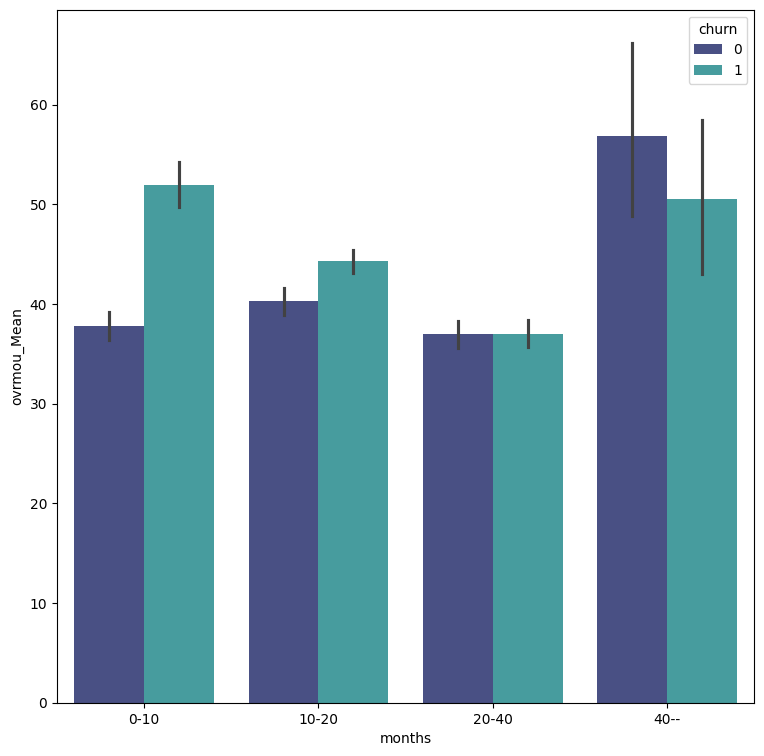

In [748]:
plt.figure(figsize=(9,9))
sns.barplot(data=final_data,x=cat_months,hue="churn",y="ovrmou_Mean",palette="mako")
plt.show()
# الناس معظمهم بيمشي في اول الشهور بسبب عدد الدقايق الزياده

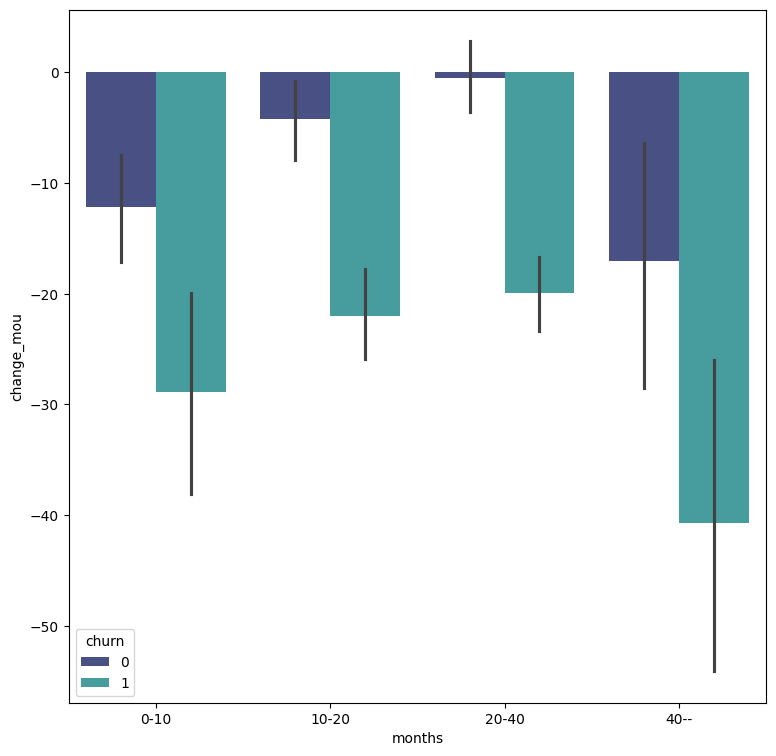

In [749]:
plt.figure(figsize=(9,9))
sns.barplot(data=final_data,x=cat_months,hue="churn",y="change_mou",palette="mako")
plt.show()

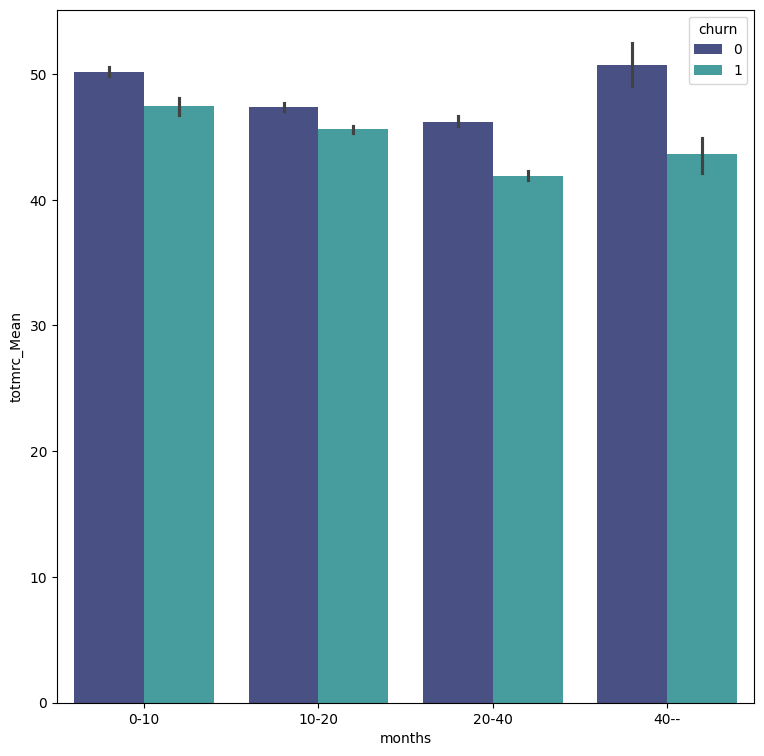

In [750]:
plt.figure(figsize=(9,9))
sns.barplot(data=final_data,x=cat_months,hue="churn",y="totmrc_Mean",palette="mako")
plt.show()

# Scatter

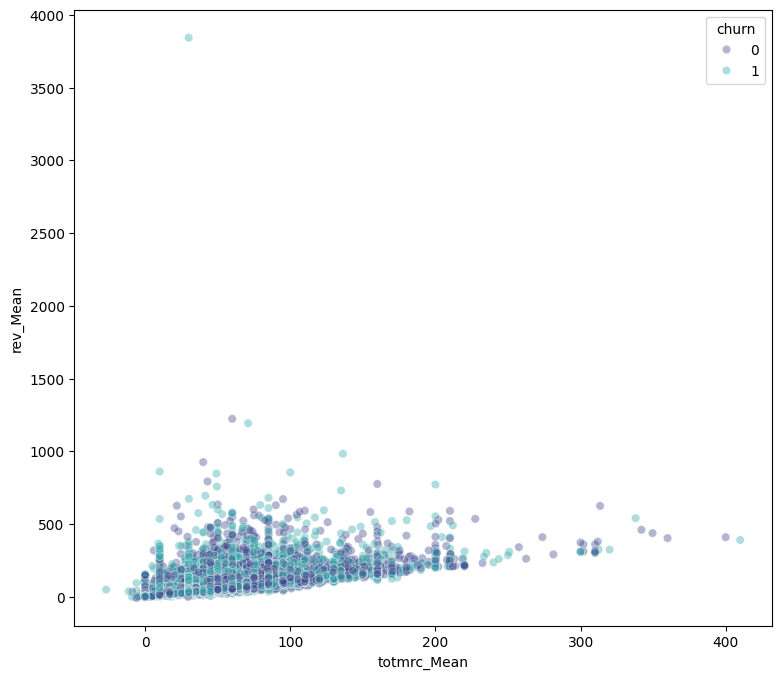

In [751]:
plt.figure(figsize=(9,8))
sns.scatterplot(data=final_data,x="totmrc_Mean",y="rev_Mean",palette="mako",hue="churn",alpha=0.4)
plt.show()

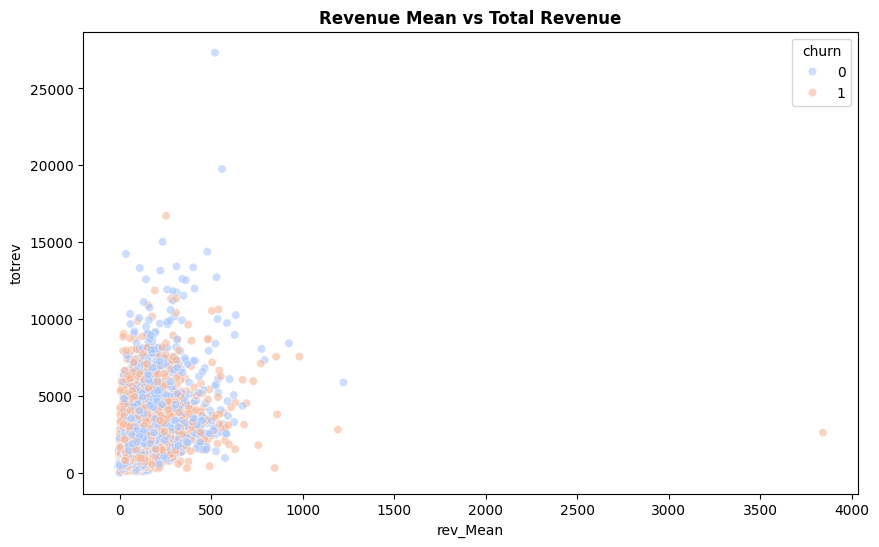

In [752]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_data, x='rev_Mean', y='totrev', hue='churn', palette='coolwarm', alpha=0.6)
plt.title('Revenue Mean vs Total Revenue', fontsize=12, weight='bold')
plt.show()

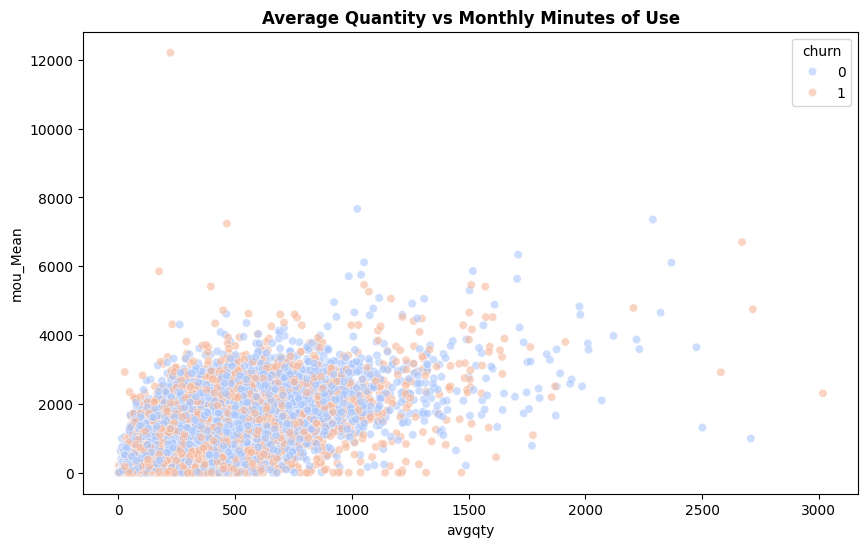

In [753]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_data, x='avgqty', y='mou_Mean', hue='churn', palette='coolwarm', alpha=0.6)
plt.title('Average Quantity vs Monthly Minutes of Use', fontsize=12, weight='bold')
plt.show()
# important

In [754]:
final_data.select_dtypes(include="number").columns

Index(['months', 'eqpdays', 'uniqsubs', 'hnd_price', 'mou_Mean', 'totmrc_Mean',
       'change_mou', 'ovrmou_Mean', 'avgqty', 'lor', 'change_rev', 'avgrev',
       'actvsubs', 'income', 'rev_Mean', 'mouiwylisv_Mean', 'totcalls',
       'drop_vce_Mean', 'totrev', 'churn'],
      dtype='str')

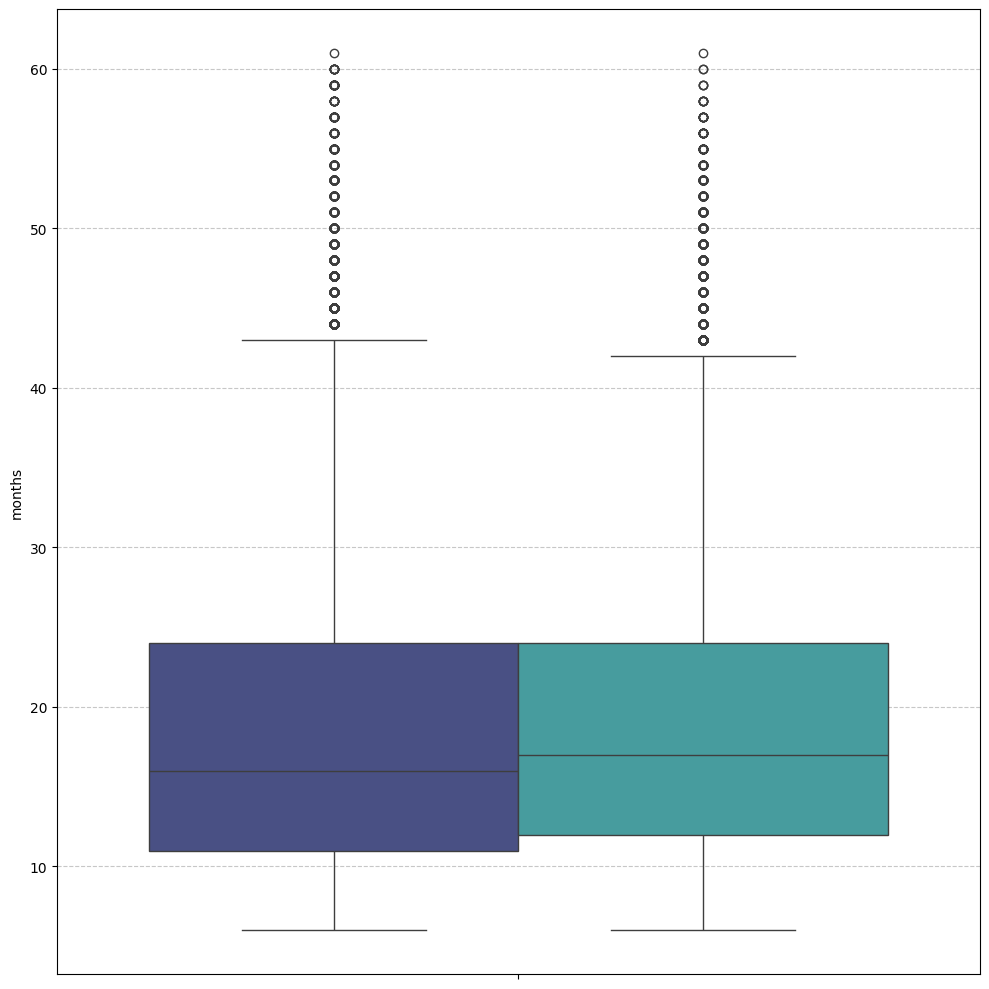

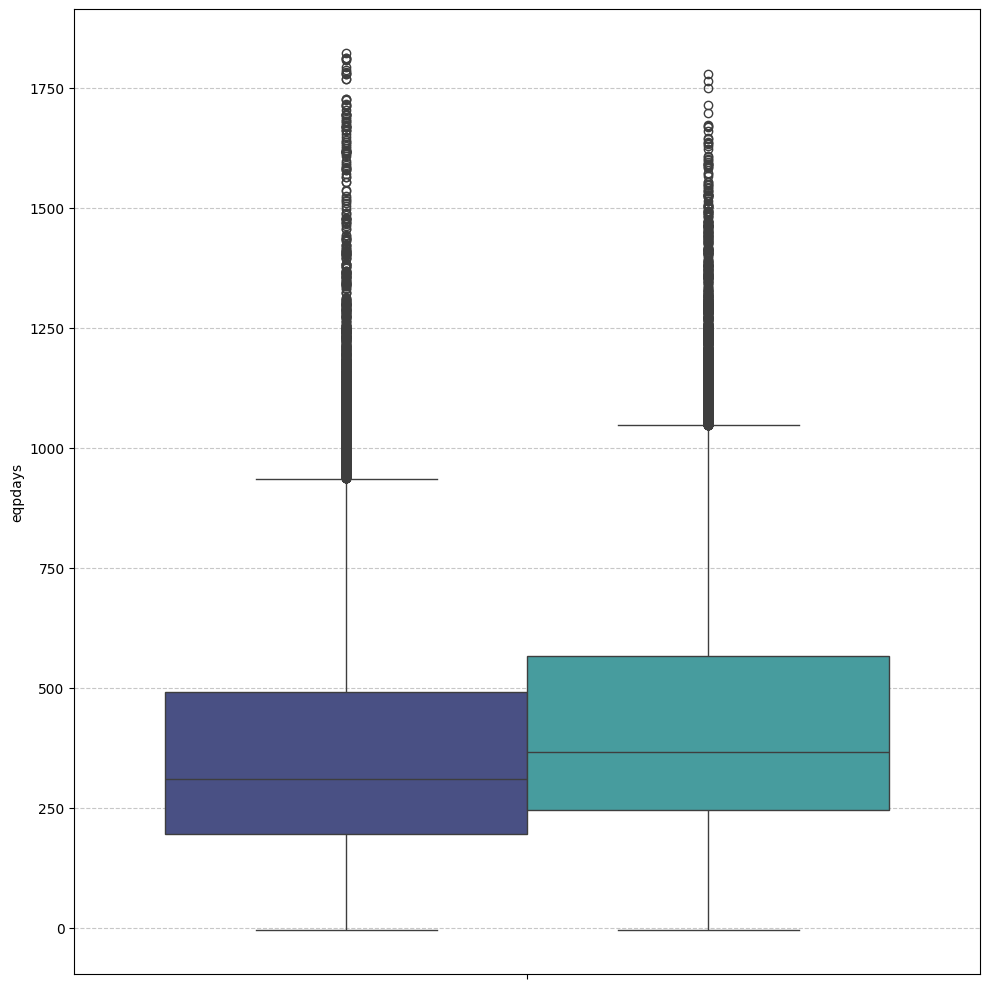

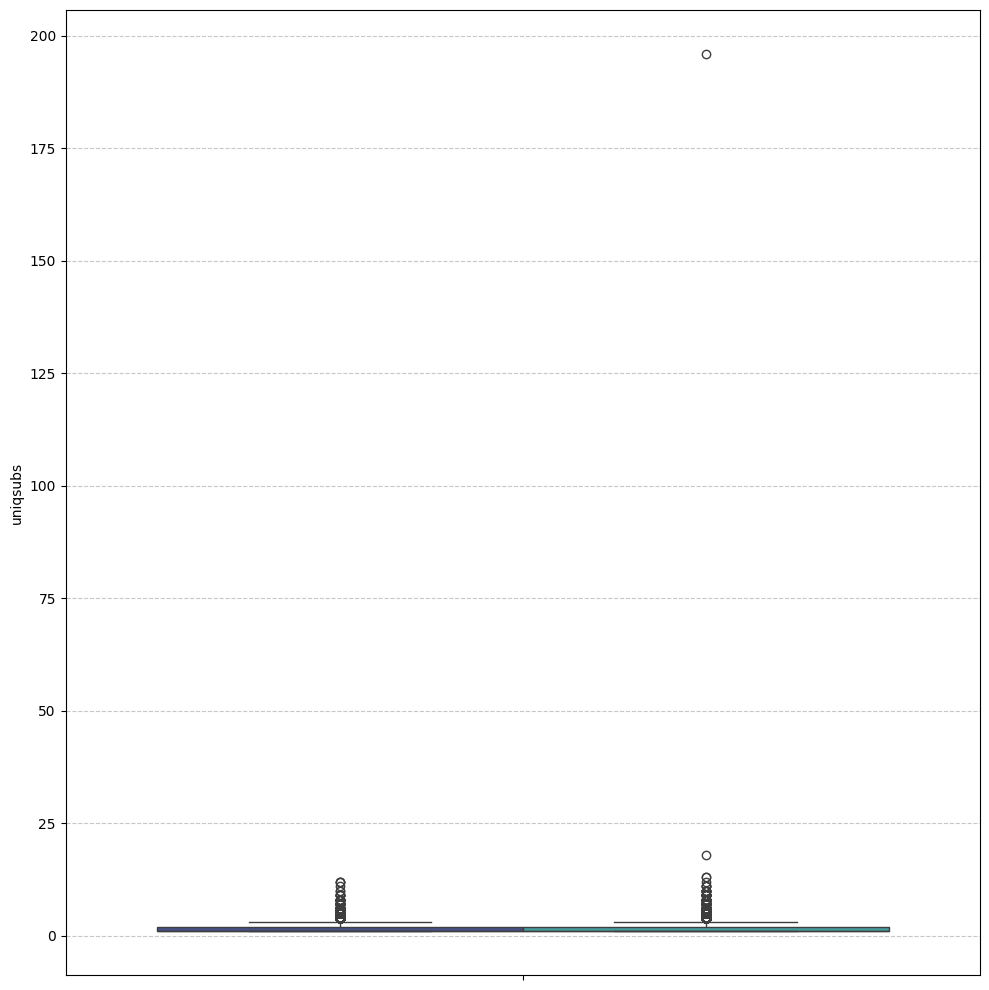

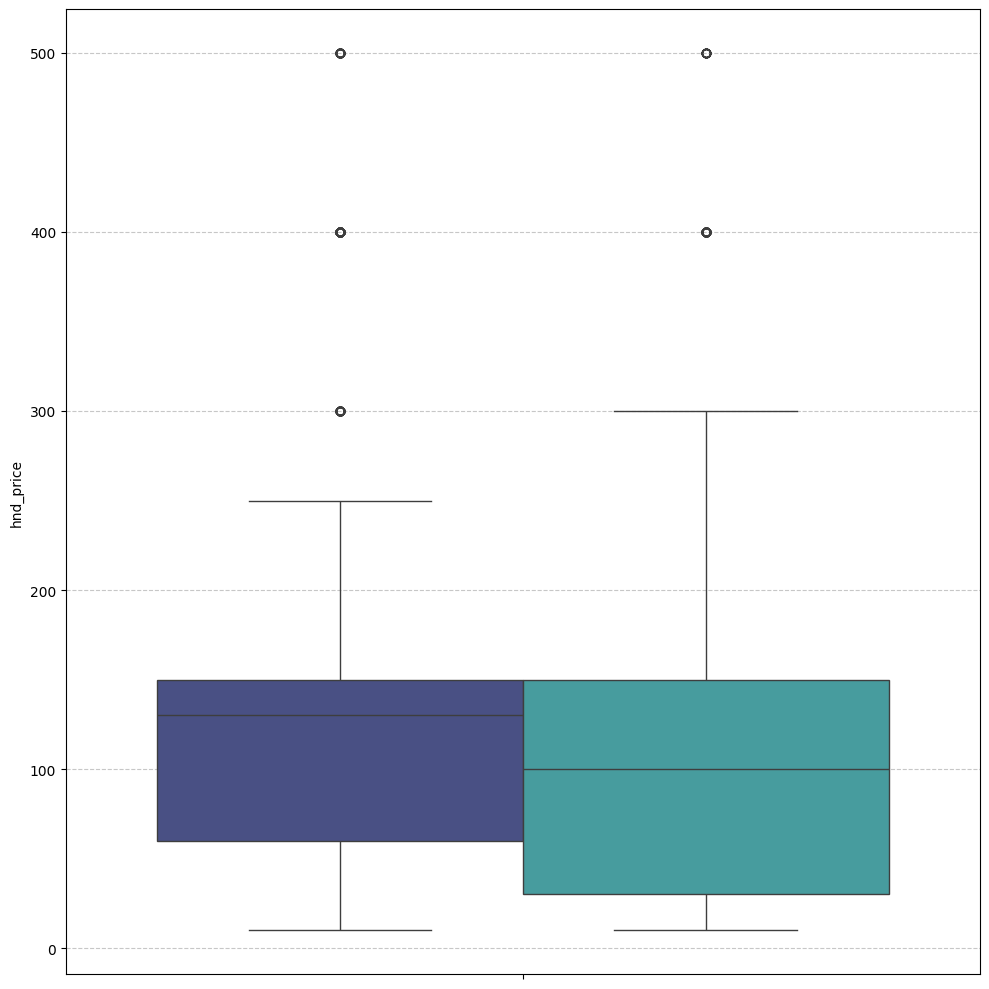

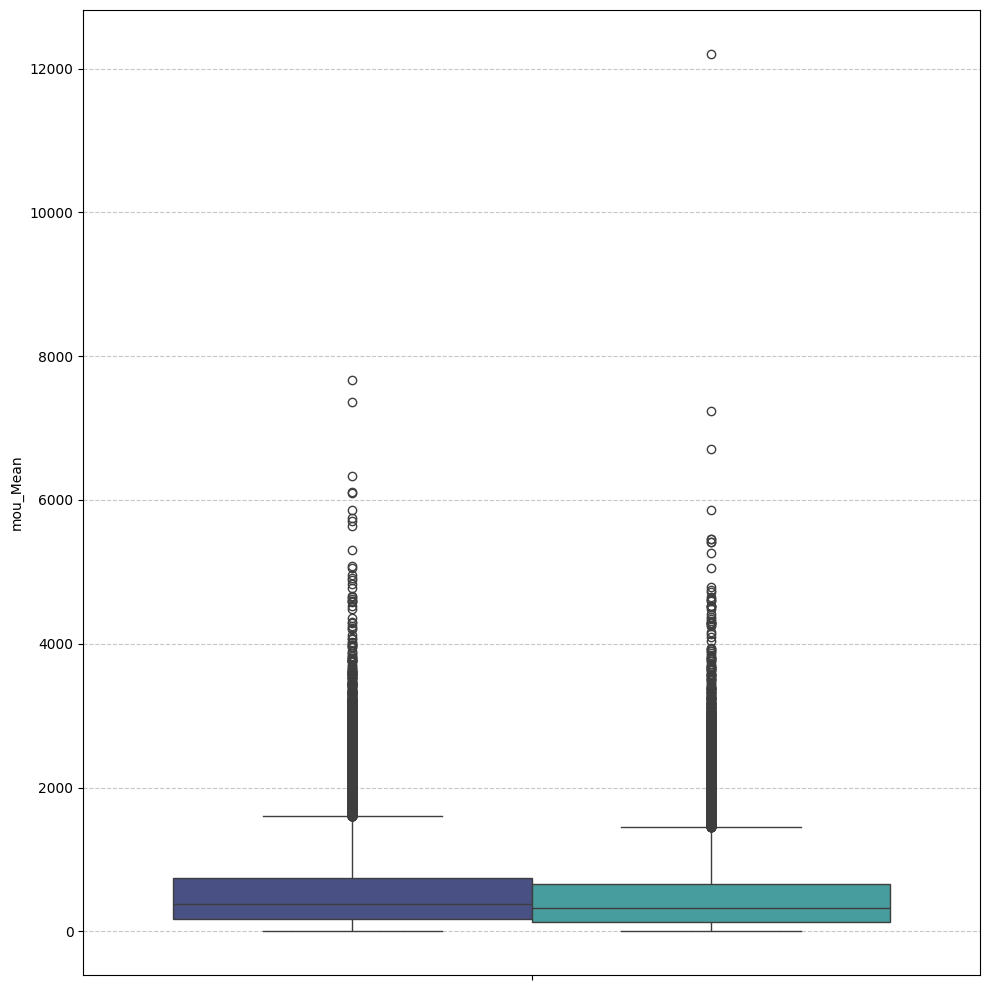

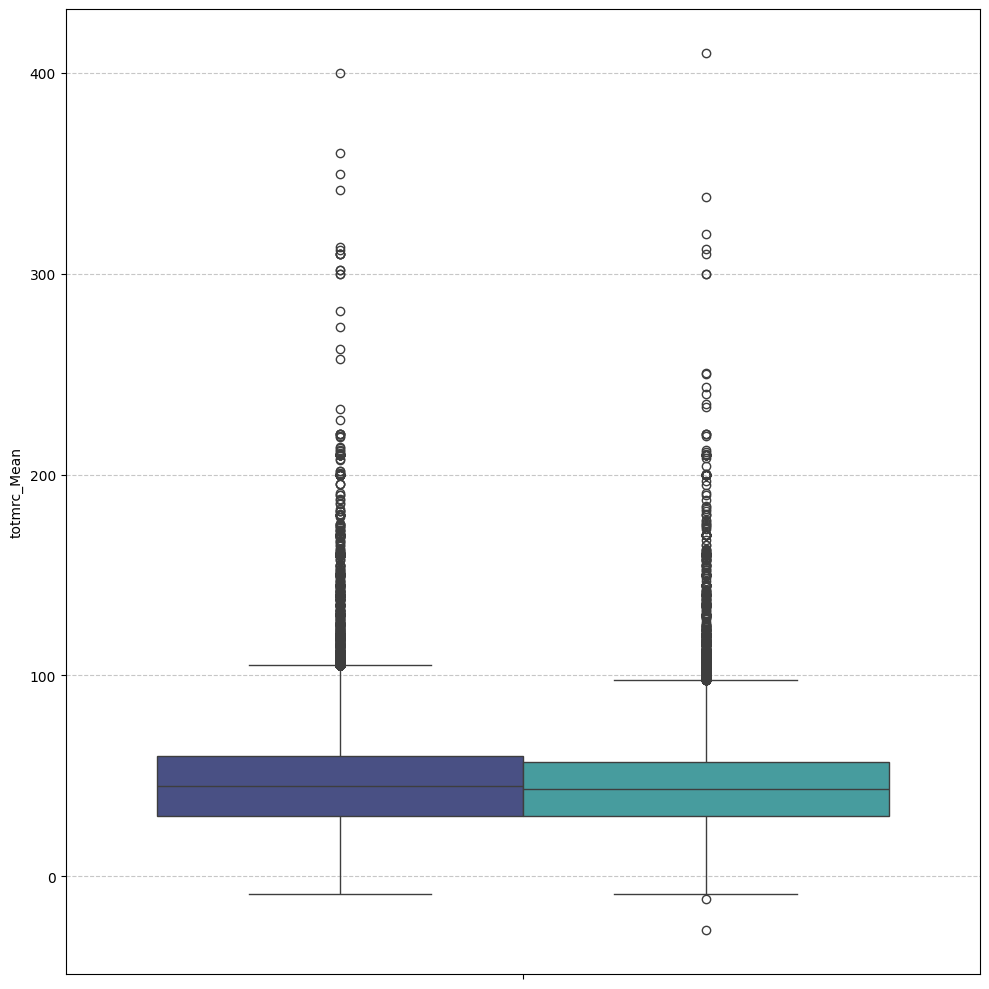

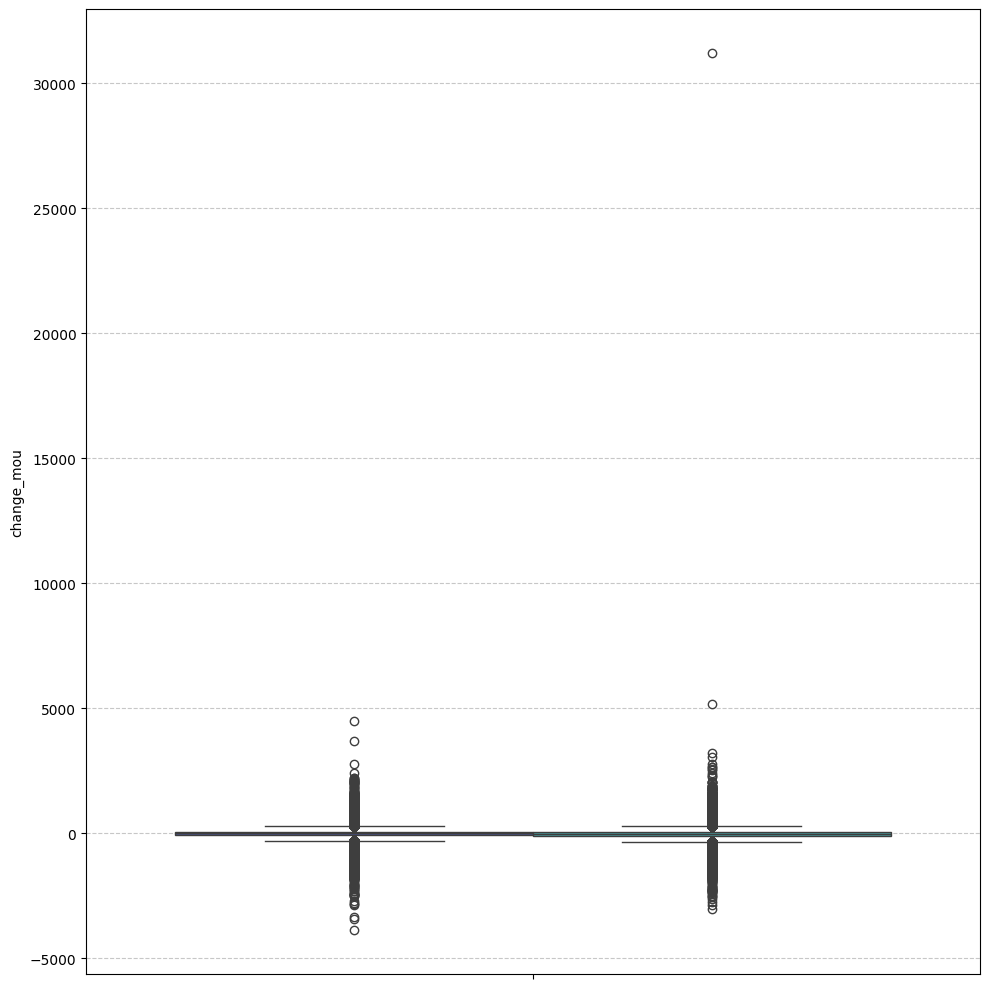

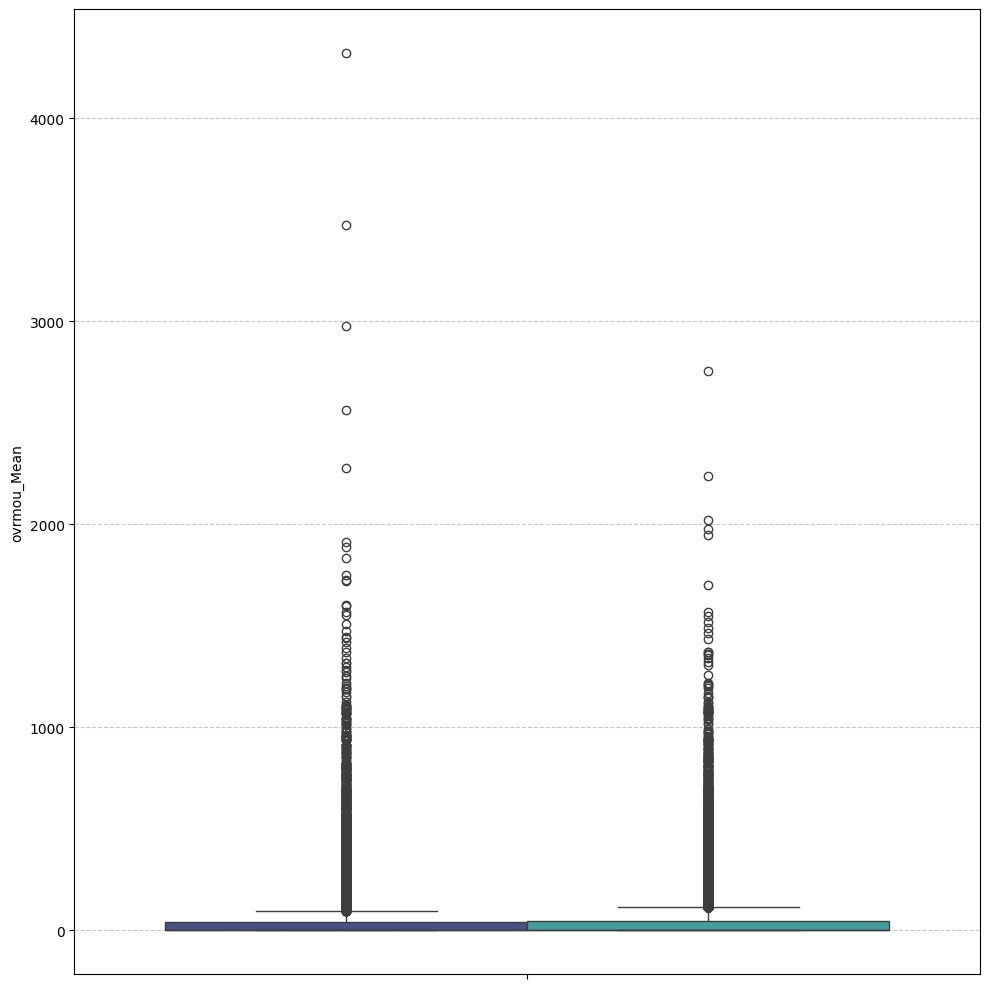

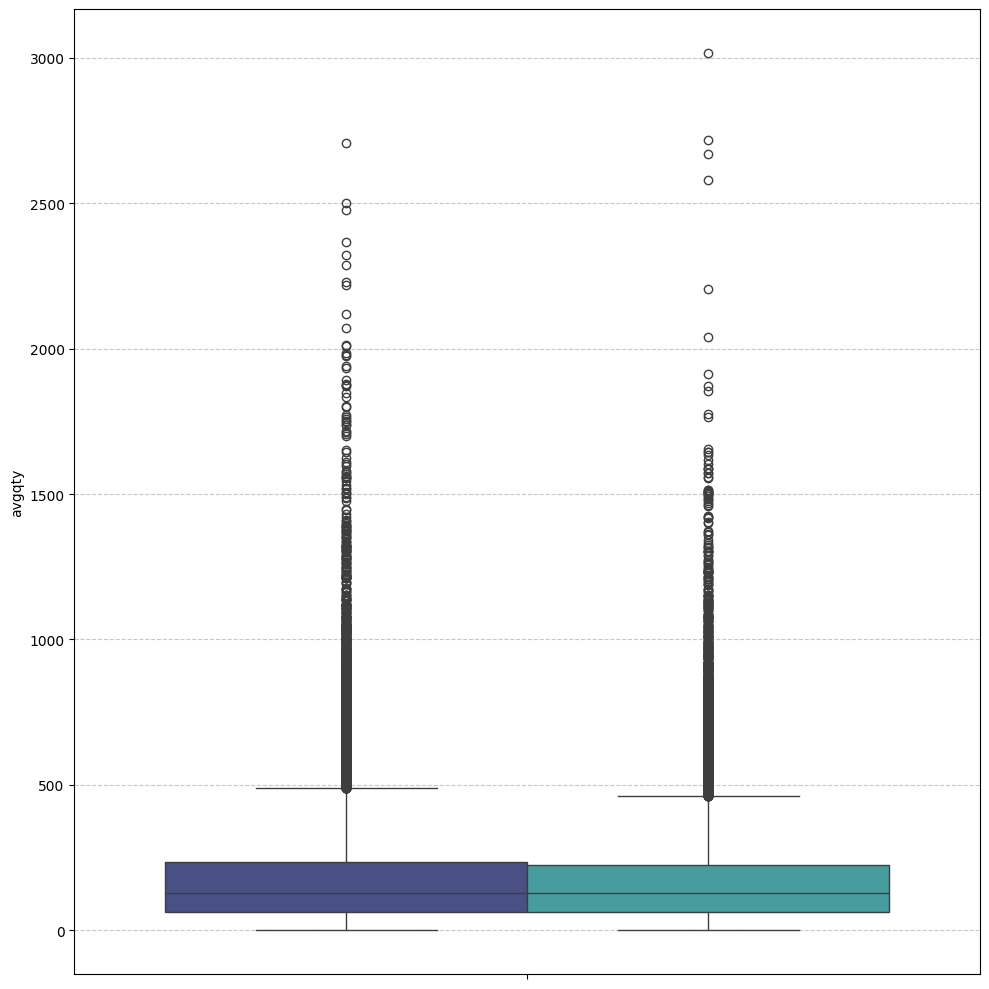

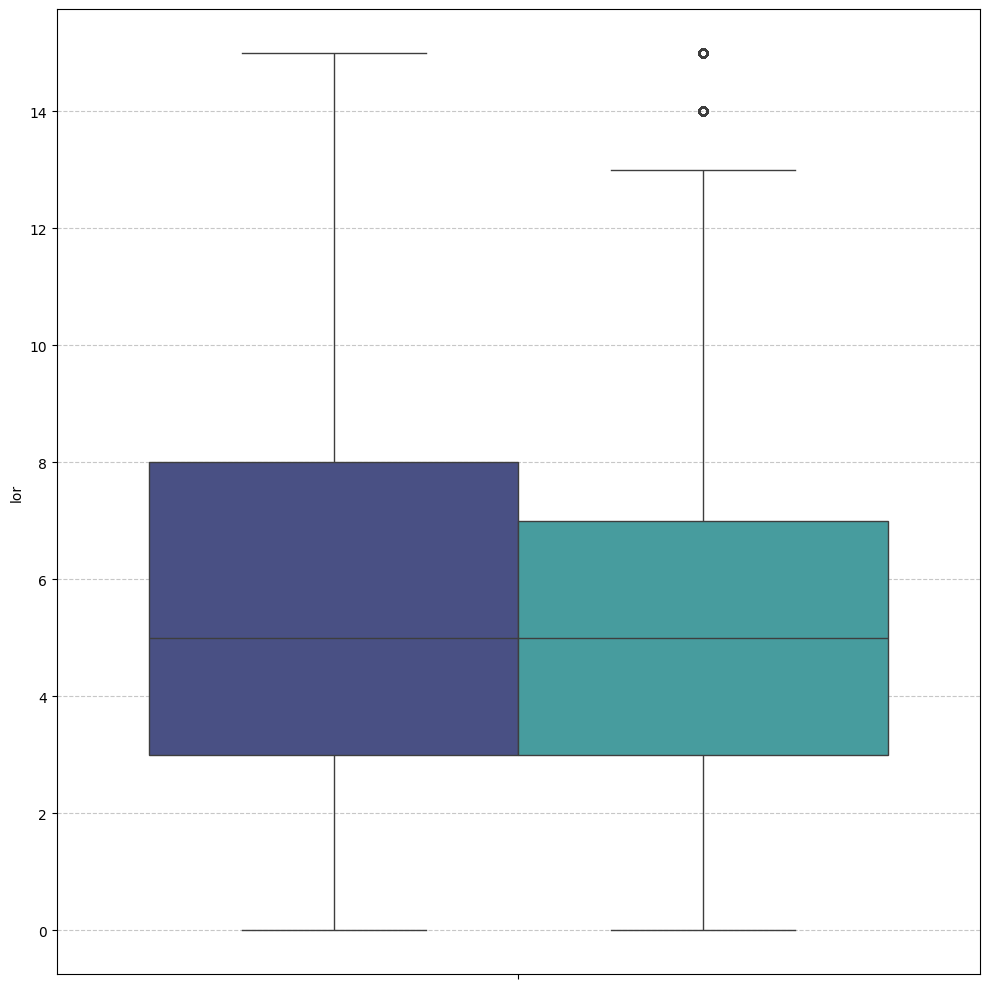

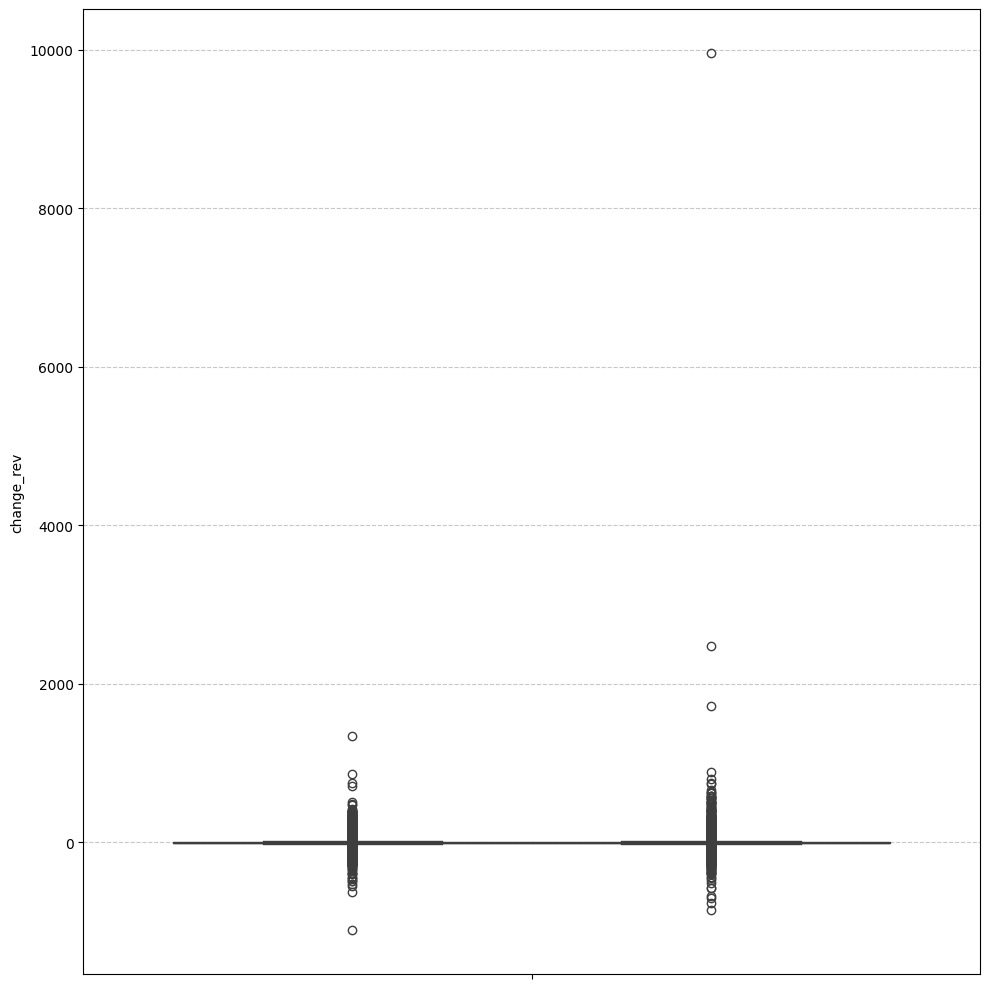

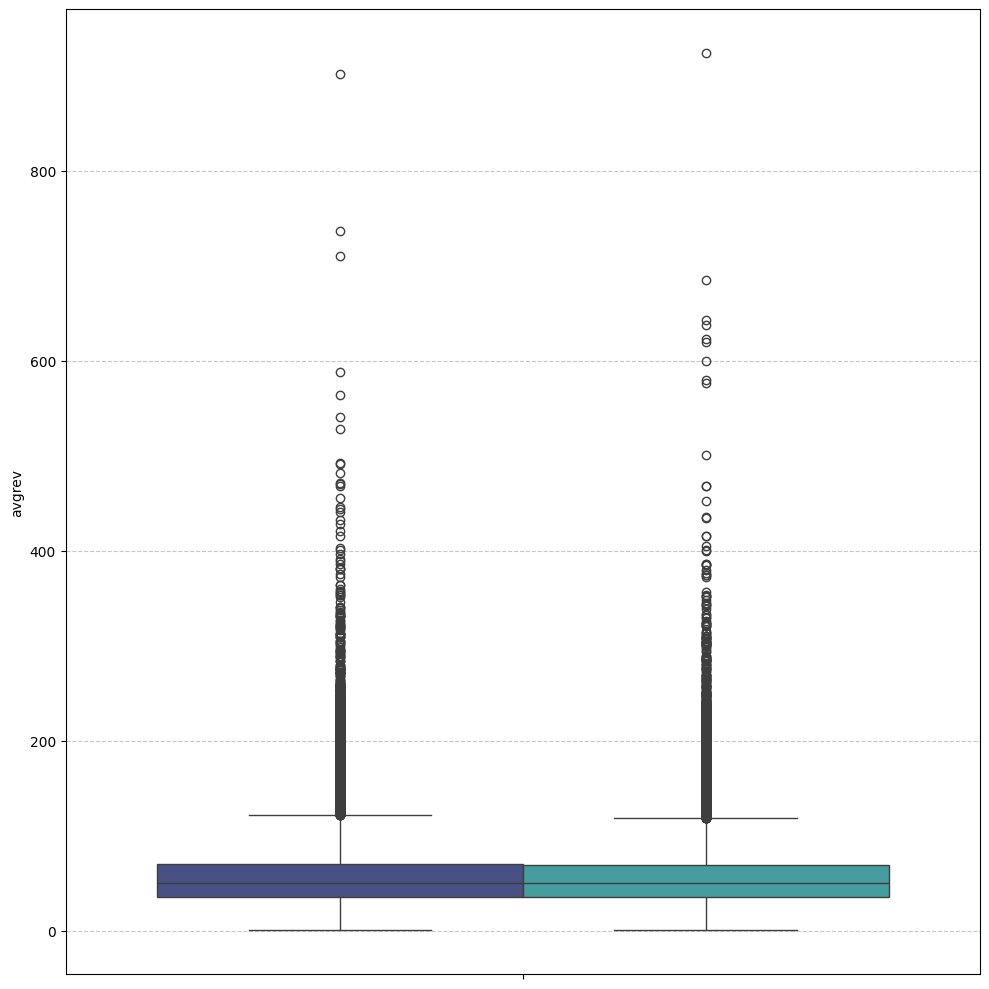

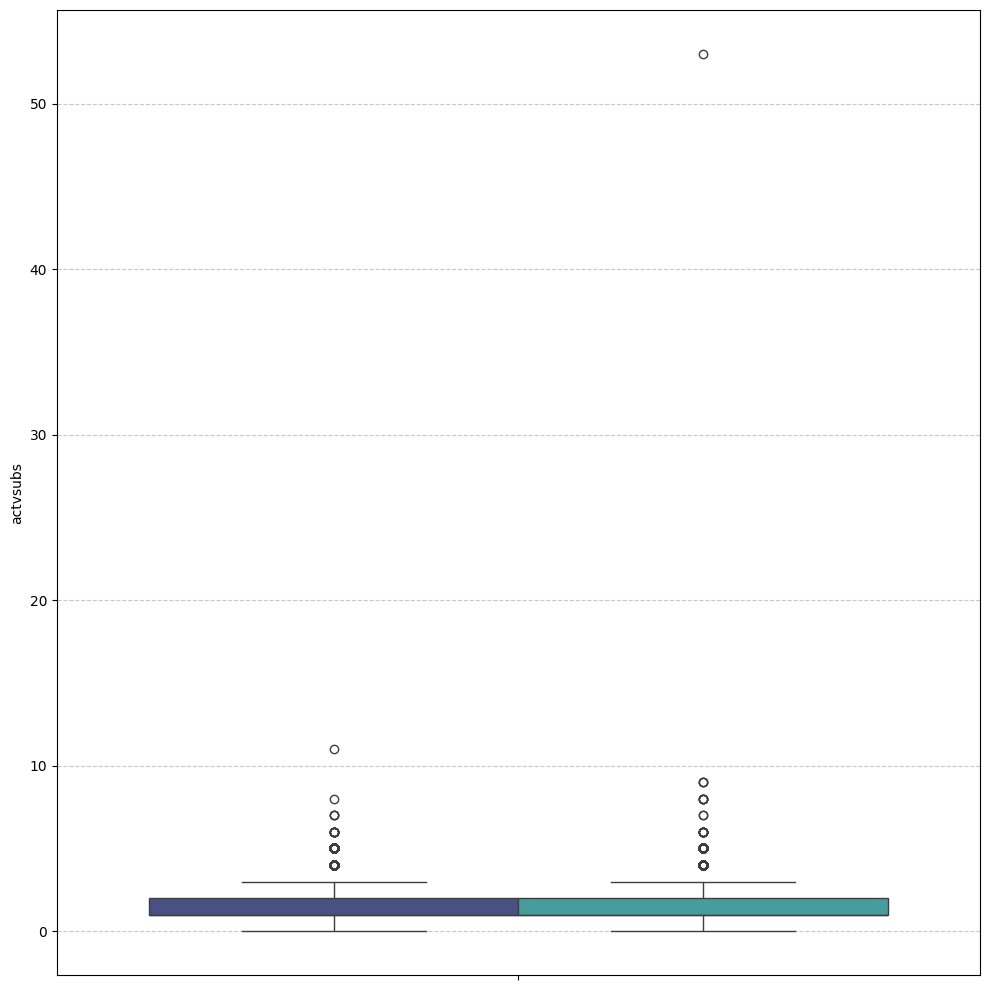

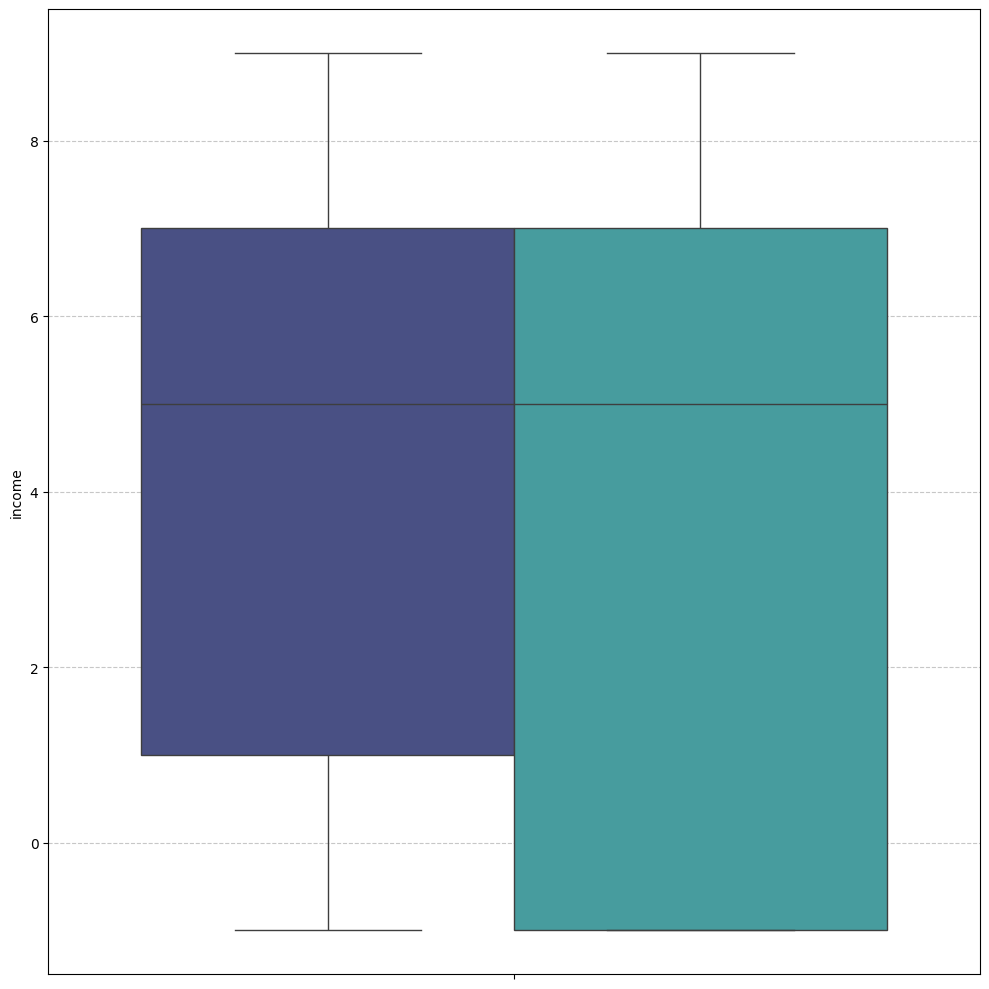

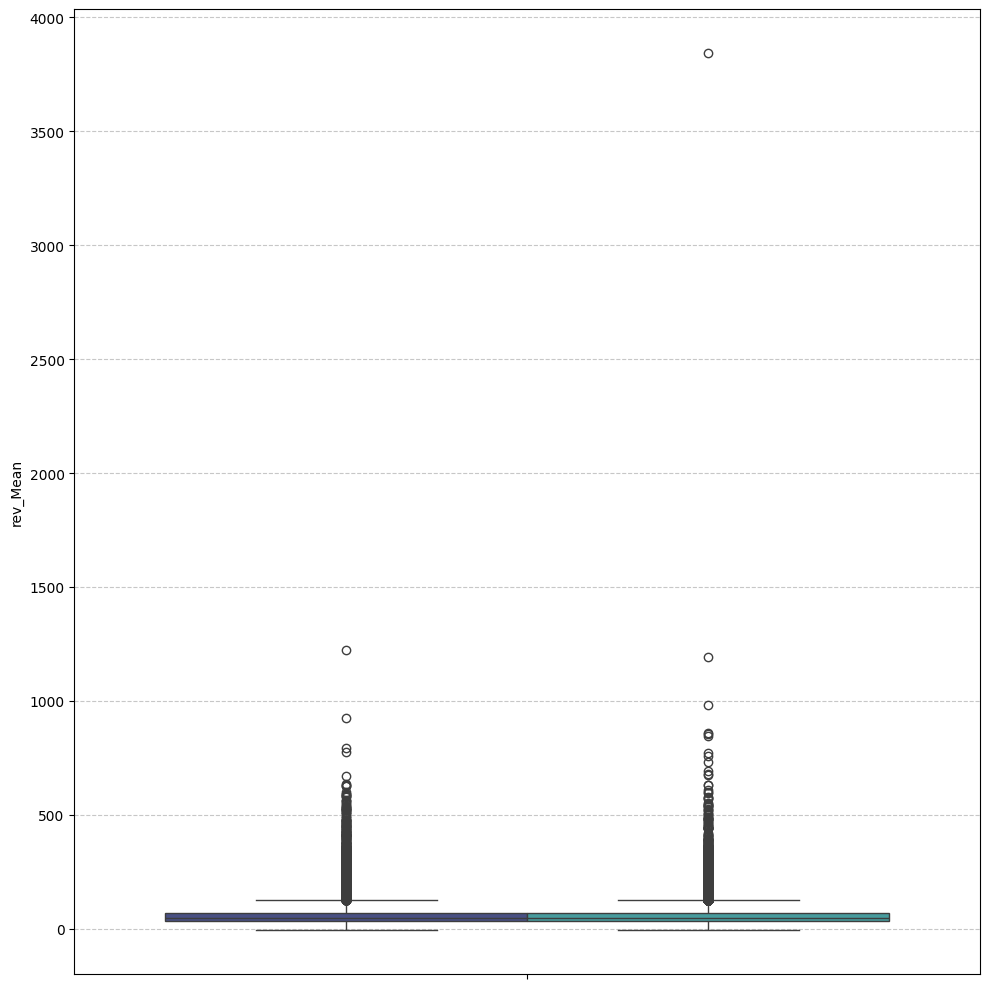

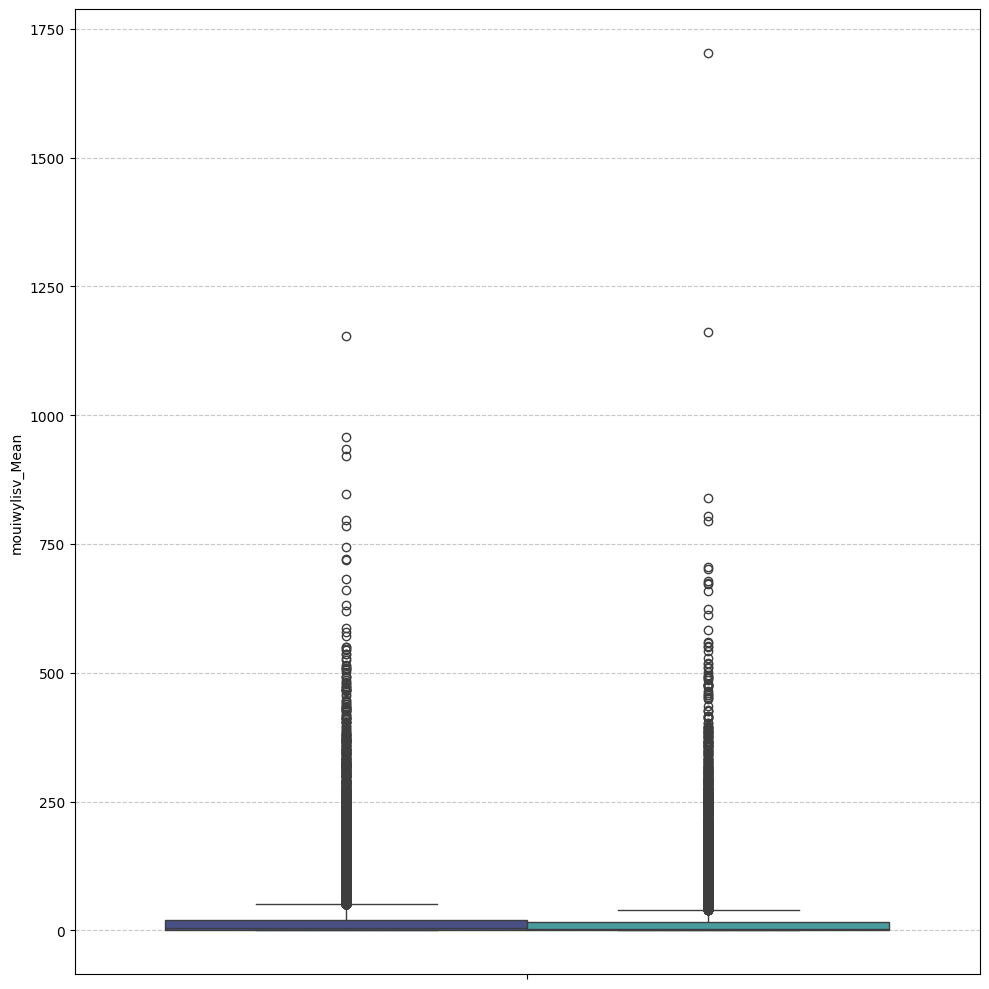

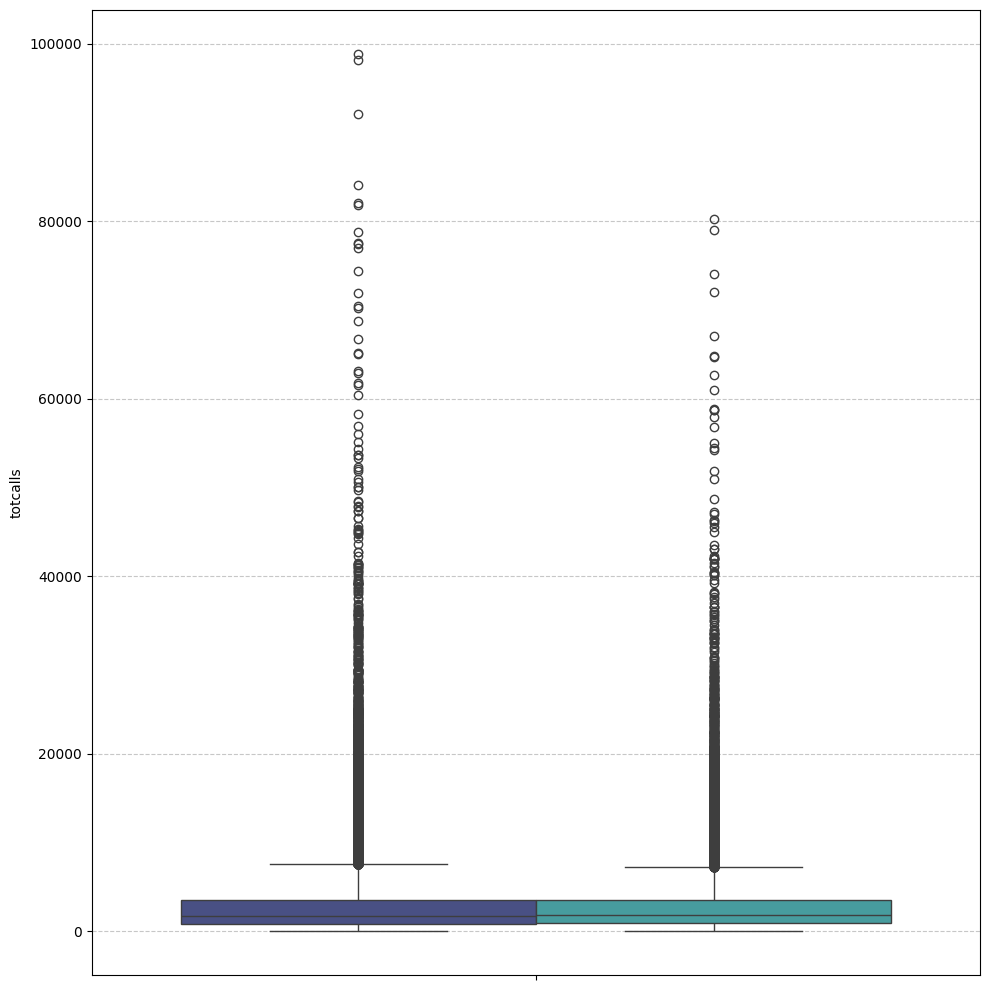

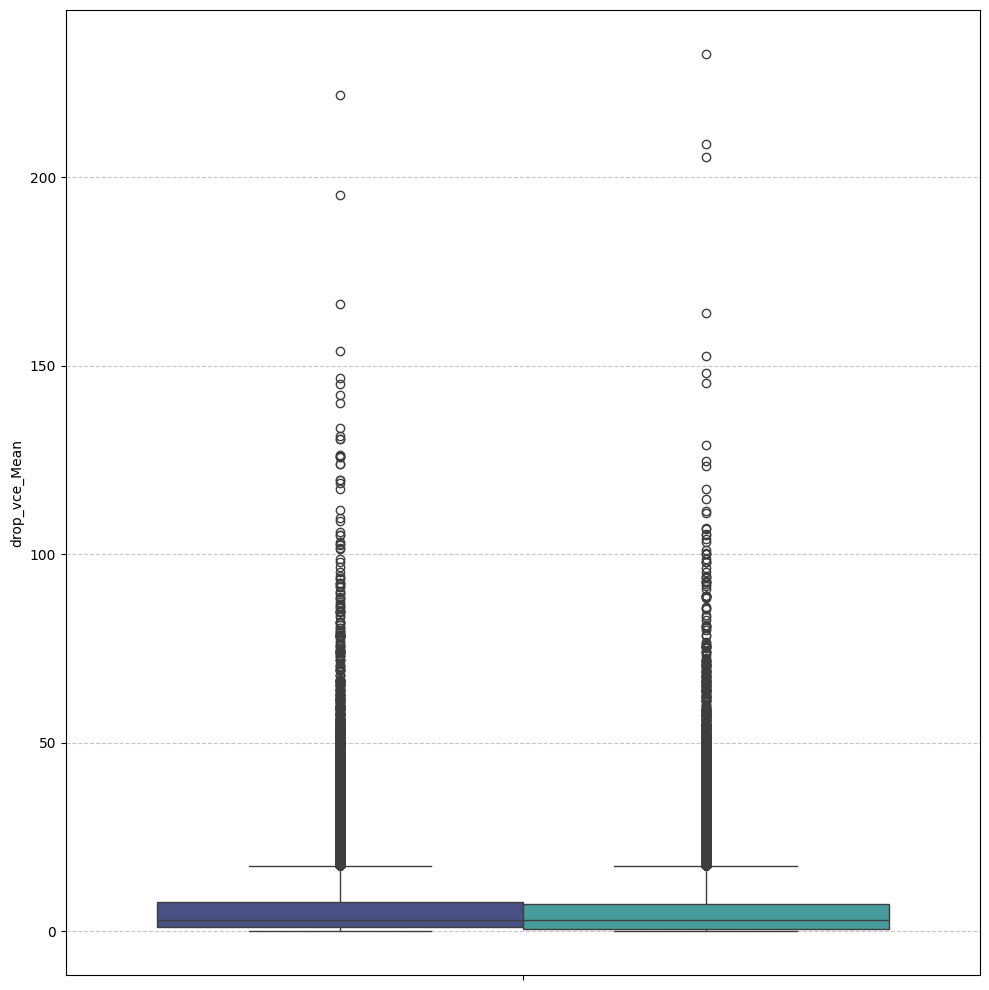

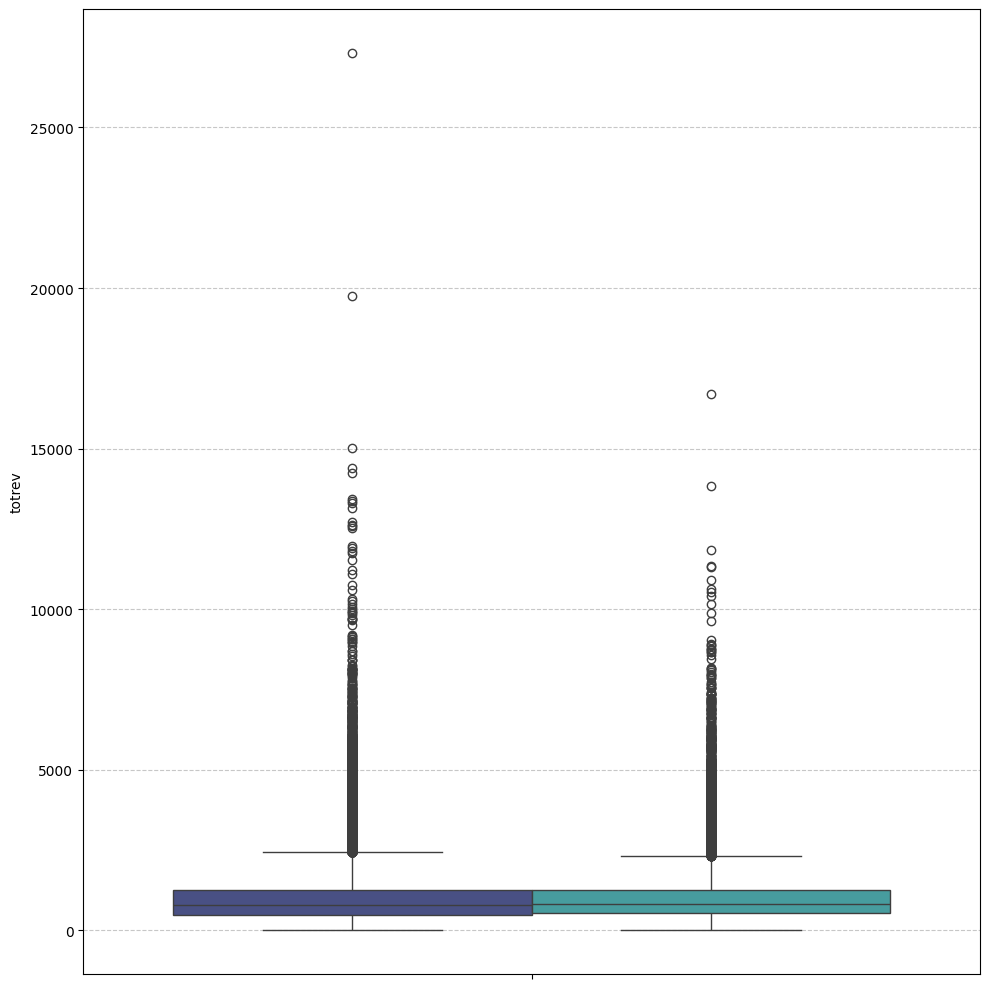

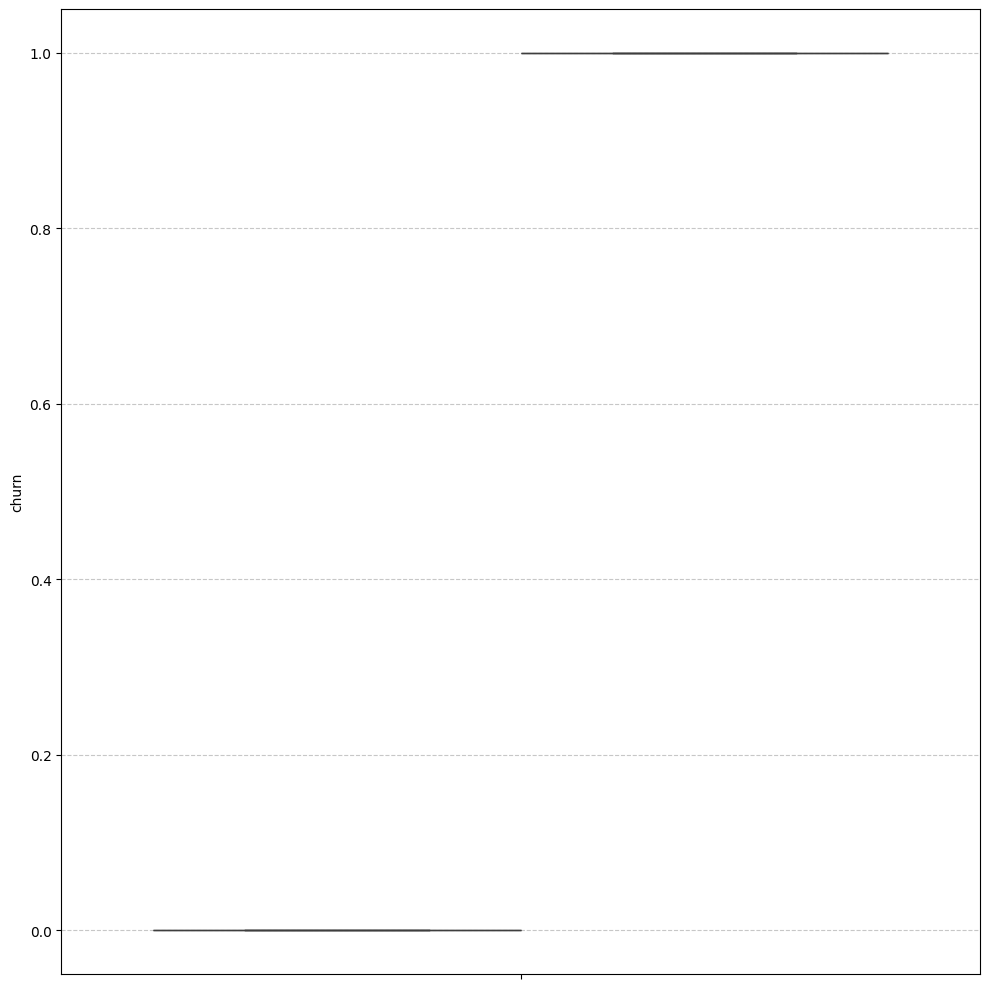

In [755]:
for col in final_data.select_dtypes(include="number").columns:
    plt.figure(figsize=(10,10))
    sns.boxplot(data=final_data,y=col,legend=False,palette="mako",hue="churn",)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Delete Outliers

In [124]:
final_data_out=final_data.copy()

In [125]:
final_data_out["totrev"]=final_data_out["totrev"].clip(upper=13000)
final_data_out["drop_vce_Mean"]=final_data_out["drop_vce_Mean"].clip(upper=125)
final_data_out["totcalls"]=final_data_out["totcalls"].clip(upper=50000)
final_data_out["avgrev"]=final_data_out["avgrev"].clip(upper=500)
final_data_out["ovrmou_Mean"]=final_data_out["ovrmou_Mean"].clip(upper=2000)

In [126]:
final_data_out["mouiwylisv_Mean"]=final_data_out["mouiwylisv_Mean"].clip(upper=650)

In [127]:
final_data_out.select_dtypes('number').columns

Index(['months', 'eqpdays', 'uniqsubs', 'hnd_price', 'mou_Mean', 'totmrc_Mean',
       'change_mou', 'ovrmou_Mean', 'avgqty', 'lor', 'change_rev', 'avgrev',
       'actvsubs', 'income', 'rev_Mean', 'mouiwylisv_Mean', 'totcalls',
       'drop_vce_Mean', 'totrev', 'churn'],
      dtype='str')

# My transform

In [128]:
from sklearn.base import BaseEstimator, TransformerMixin
class MyTransformer(BaseEstimator,TransformerMixin):
    def __init__(self, network_frustration_feature=True, bill_shock_ratio_feature=True, eqp_age_ratio_feature=True, usage_intensity_feature=True):
        self.network_frustration_feature = network_frustration_feature
        self.bill_shock_ratio_feature = bill_shock_ratio_feature
        self.eqp_age_ratio_feature = eqp_age_ratio_feature
        self.usage_intensity_feature = usage_intensity_feature
    
    def fit (self,X,y=None):
        return self
    
    def transform(self,X):
        X=X.copy()
        
        edits=[]
                    
        if self.network_frustration_feature and "drop_vce_Mean" in X.columns and "mouiwylisv_Mean" in X.columns:
            network_frustration = X["drop_vce_Mean"] * X["mouiwylisv_Mean"]
            network_frustration.name = "network_frustration"
            edits.append(network_frustration)
        
        if self.bill_shock_ratio_feature and "ovrmou_Mean" in X.columns and "totmrc_Mean" in X.columns:
            bill_shock_ratio = X["ovrmou_Mean"] / (X["totmrc_Mean"] + 0.00001)
            bill_shock_ratio.name = "bill_shock_ratio"
            edits.append(bill_shock_ratio)
        
        if self.eqp_age_ratio_feature and "eqpdays" in X.columns and "months" in X.columns:
            eqp_age_ratio = X["eqpdays"] / (X["months"] + 0.0001)
            eqp_age_ratio.name = "eqp_age_ratio"
            edits.append(eqp_age_ratio)
            
        if self.usage_intensity_feature and "totcalls" in X.columns and "months" in X.columns:
            usage_intensity = X["totcalls"] / (X["months"] + 0.0001)
            usage_intensity.name = "usage_intensity"
            edits.append(usage_intensity)
        
        
        
        if edits:
            X=pd.concat([X] + edits,axis=1)
        return X
            
            
        
            

# Last touch on the data

In [129]:
final_data_out.isna().sum()

months                0
refurb_new            1
eqpdays               1
asl_flag              0
uniqsubs              0
hnd_price           847
mou_Mean            357
hnd_webcap            0
totmrc_Mean         357
change_mou          891
creditcd           1732
ovrmou_Mean         357
avgqty                0
lor                   0
change_rev          891
avgrev                0
actvsubs              0
income                0
rev_Mean            357
mouiwylisv_Mean       0
dualband              1
marital            1732
totcalls              0
drop_vce_Mean         0
totrev                0
churn                 0
dtype: int64

In [130]:
len(list(final_data_out.select_dtypes(include="number").columns))

20

In [131]:
len(list(final_data_out.select_dtypes(include="object").columns))

C:\Users\Access\AppData\Local\Temp\ipykernel_15824\1804521200.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  len(list(final_data_out.select_dtypes(include="object").columns))


6

In [132]:
for x in list(final_data_out.select_dtypes(include="object").columns):
    print(x)
    print(final_data_out[x].unique())

refurb_new
<StringArray>
['N', 'R', nan]
Length: 3, dtype: str
asl_flag
<StringArray>
['N', 'Y']
Length: 2, dtype: str
hnd_webcap
<StringArray>
['WCMB', 'WC', 'Missing', 'UNKW']
Length: 4, dtype: str
creditcd
<StringArray>
['Y', 'N', nan]
Length: 3, dtype: str
dualband
<StringArray>
['Y', 'N', 'T', 'U', nan]
Length: 5, dtype: str
marital
<StringArray>
['S', 'M', 'A', 'U', 'B', nan]
Length: 6, dtype: str


C:\Users\Access\AppData\Local\Temp\ipykernel_15824\3261596210.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for x in list(final_data_out.select_dtypes(include="object").columns):


In [133]:
cat_one_hot_cols=["asl_flag","refurb_new","hnd_webcap","creditcd"]
cat_ordinal_cols=["dualband","marital"]

In [134]:
from sklearn.preprocessing import RobustScaler,OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Pipe Lines

In [135]:
num_pipe=Pipeline(
    steps=[
        ("num_imputer",SimpleImputer(strategy="median")),
        ("scaler",RobustScaler())
    ]
)

cat_one_hot_pipe=Pipeline(
    steps=[
        ("cat_one_impute",SimpleImputer(strategy="most_frequent")),
        ("one_hot_encoder",OneHotEncoder(handle_unknown="ignore",sparse_output=False))
    ]
)

cat_ordinal_pipe=Pipeline(steps=[
    ("ordinal_impute",SimpleImputer(strategy="most_frequent")),
    ("oredinal_emcoder",OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1))
])

# Column Transformers

In [136]:
from sklearn.compose import make_column_selector

In [137]:
col_transformer=ColumnTransformer(transformers=[
    ("num_transformer",num_pipe,make_column_selector(dtype_include="number")),
    ("one_hot_transformer",cat_one_hot_pipe,cat_one_hot_cols,),
    ("ordinal_transformer",cat_ordinal_pipe,cat_ordinal_cols)
])

# Fine-tuning Pipe

# Prepare Data

In [138]:
from sklearn.model_selection import StratifiedShuffleSplit

# Non Outlier Date

In [140]:
fine_splitter=StratifiedShuffleSplit(random_state=42,n_splits=1,test_size=0.2)

for train_index,test_index in fine_splitter.split(final_data_out,final_data_out["churn"]):
    
    strat_train_fine=final_data_out.loc[train_index]
    strat_test_fine=final_data_out.loc[test_index]


In [141]:
strat_x_fine_train=strat_train_fine.drop("churn",axis=1)
strat_y_fine_train=strat_train_fine["churn"]

strat_x_fine_test=strat_test_fine.drop("churn",axis=1)
strat_y_fine_test=strat_test_fine["churn"]

# Outlier Date

In [142]:
fine_splitter=StratifiedShuffleSplit(random_state=42,n_splits=1,test_size=0.2)

for train_index,test_index in fine_splitter.split(final_data,final_data["churn"]):
    
    strat_train_fine_mode=final_data.loc[train_index]
    strat_test_fine_mode=final_data.loc[test_index]


In [143]:
strat_x_fine_train_mode=strat_train_fine.drop("churn",axis=1)
strat_y_fine_train_mode=strat_train_fine["churn"]

strat_x_fine_test_mode=strat_test_fine.drop("churn",axis=1)
strat_y_fine_test_mode=strat_test_fine["churn"]

In [144]:
print(strat_x_fine_test_mode.shape)
print(strat_x_fine_test.shape)

(20000, 25)
(20000, 25)


# Start Fine Tuning

# XGB

In [145]:
from xgboost import XGBClassifier

In [146]:
from sklearn.model_selection import RandomizedSearchCV

In [826]:
xgb_params={
    "new_feature__network_frustration_feature": [True, False],
    "new_feature__bill_shock_ratio_feature": [True, False],
    "new_feature__eqp_age_ratio_feature": [True, False],
    "new_feature__usage_intensity_feature": [True, False],
    
    "model__n_estimators":[100,200,300,400,500],
    "model__learning_rate":[0.01,0.05,0.1,0.005,0.2,0.5],
    "model__max_depth":[3,7,10,16],
    
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__scale_pos_weight": [1, 2, 3, 4, 5]
    
}

In [827]:
fine_tuning_pipe_xgb=Pipeline(
    steps=[
        ("new_feature",MyTransformer()),
        ("transformer",col_transformer),
        ("model",XGBClassifier())
    ]
)

In [830]:
random_search_xgb=RandomizedSearchCV(
    estimator=fine_tuning_pipe_xgb,
    param_distributions=xgb_params,
    n_iter=20,
    scoring="f1",
    cv=5,
    verbose=3,
    n_jobs=1,
    random_state=43
)

In [831]:
random_search_xgb.fit(strat_x_fine_train,strat_y_fine_train)
print("Best Params" ,random_search_xgb.best_params_)
print("Best Score", random_search_xgb.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END model__colsample_bytree=0.6, model__learning_rate=0.05, model__max_depth=16, model__n_estimators=100, model__scale_pos_weight=2, model__subsample=1.0, new_feature__bill_shock_ratio_feature=True, new_feature__eqp_age_ratio_feature=False, new_feature__network_frustration_feature=True, new_feature__usage_intensity_feature=True;, score=0.669 total time=  55.1s
[CV 2/5] END model__colsample_bytree=0.6, model__learning_rate=0.05, model__max_depth=16, model__n_estimators=100, model__scale_pos_weight=2, model__subsample=1.0, new_feature__bill_shock_ratio_feature=True, new_feature__eqp_age_ratio_feature=False, new_feature__network_frustration_feature=True, new_feature__usage_intensity_feature=True;, score=0.668 total time=  48.8s
[CV 3/5] END model__colsample_bytree=0.6, model__learning_rate=0.05, model__max_depth=16, model__n_estimators=100, model__scale_pos_weight=2, model__subsample=1.0, new_feature__bill_shock_ratio_

# With None Outliers

In [147]:
final_pipe_xgb=Pipeline(
    steps=[
        ("new_feature",MyTransformer(usage_intensity_feature=False,network_frustration_feature=False,eqp_age_ratio_feature=True,bill_shock_ratio_feature=False)),
        ("transformer",col_transformer),
        ("model",XGBClassifier(subsample=0.7,scale_pos_weight=2,n_estimators=400,max_depth=10,learning_rate=0.01,colsample_bytree=0.6))
    ]
)

In [148]:
final_pipe_xgb.fit(strat_x_fine_train,strat_y_fine_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('new_feature', ...), ('transformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,network_frustration_feature,False
,bill_shock_ratio_feature,False
,usage_intensity_feature,False
,eqp_age_ratio_feature,True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_transformer', ...), ('one_hot_transformer', ...), ...]"


In [149]:
from sklearn.metrics import classification_report

In [ ]:
y_pred=final_pipe_xgb.predict(strat_x_fine_test)
print(classification_report(strat_y_fine_test,y_pred))

# With Outlier

In [151]:
class MyTransformerV2(BaseEstimator, TransformerMixin):
    def __init__(self, device_upgrade_urgency_feature=True, phone_affordability_feature=True, web_target_feature=True):
        self.device_upgrade_urgency_feature = device_upgrade_urgency_feature
        self.phone_affordability_feature = phone_affordability_feature
        self.web_target_feature = web_target_feature
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        edits = []
        
        if self.device_upgrade_urgency_feature and "eqpdays" in X.columns and "months" in X.columns:
            upgrade_urgency = X["eqpdays"] / (X["months"] + 0.0001)
            upgrade_urgency.name = "device_upgrade_urgency"
            edits.append(upgrade_urgency)
            
        if self.phone_affordability_feature and "income" in X.columns and "totmrc_Mean" in X.columns:
            affordability_score = X["income"] * X["totmrc_Mean"]
            affordability_score.name = "phone_affordability_score"
            edits.append(affordability_score)
            
        if self.web_target_feature and "income" in X.columns and "eqpdays" in X.columns:
            web_target = X["income"] * X["eqpdays"]
            web_target.name = "income_vs_device_age"
            edits.append(web_target)
            
        if edits:
            X = pd.concat([X] + edits, axis=1)
        return X

In [152]:
final_pipe_xgb_mode=Pipeline(
    steps=[
        ("new_feature",MyTransformer(usage_intensity_feature=False,network_frustration_feature=False,eqp_age_ratio_feature=True,bill_shock_ratio_feature=False)),
        ("new_feature_2",MyTransformerV2()),
        ("transformer",col_transformer),
        ("model",XGBClassifier(subsample=0.7,scale_pos_weight=2,n_estimators=400,max_depth=10,learning_rate=0.01,colsample_bytree=0.6))
    ]
)

In [153]:
final_pipe_xgb_mode.fit(strat_x_fine_train_mode,strat_y_fine_train_mode)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('new_feature', ...), ('new_feature_2', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,network_frustration_feature,False
,bill_shock_ratio_feature,False
,usage_intensity_feature,False
,eqp_age_ratio_feature,True
,device_upgrade_urgency_feature,True


In [154]:
y_pred=final_pipe_xgb_mode.predict(strat_x_fine_test_mode)
print(classification_report(strat_y_fine_test_mode,y_pred))

              precision    recall  f1-score   support

           0       0.74      0.28      0.40     10088
           1       0.55      0.90      0.68      9912

    accuracy                           0.59     20000
   macro avg       0.65      0.59      0.54     20000
weighted avg       0.65      0.59      0.54     20000



# Random Forest

In [68]:
from sklearn.ensemble import RandomForestClassifier

In [833]:
fine_tuning_pipe_rf=Pipeline(
    steps=[
        ("new_feature",MyTransformer()),
        ("transformer",col_transformer),
        ("model",RandomForestClassifier())
    ]
)

In [834]:
rf_params = {
    "new_feature__network_frustration_feature": [True, False],
    "new_feature__bill_shock_ratio_feature": [True, False],
    "new_feature__eqp_age_ratio_feature": [True, False],
    "new_feature__usage_intensity_feature": [True, False],
    
    "model__n_estimators": [100, 200, 300, 400, 500],
    "model__max_depth": [3, 7, 10, 16, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    
    "model__max_features": ["sqrt", "log2", 0.6, 0.8, None],
    "model__bootstrap": [True, False],
    
    "model__class_weight": [None, "balanced", "balanced_subsample"]
}

In [835]:
random_search_rf=RandomizedSearchCV(
    estimator=fine_tuning_pipe_rf,
    param_distributions=rf_params,
    n_iter=20,
    scoring="f1",
    cv=5,
    verbose=3,
    n_jobs=1,
    random_state=43
)

In [ ]:
random_search_rf.fit(strat_x_fine_train,strat_y_fine_train)
print("Best Params" ,random_search_rf.best_params_)
print("Best Score", random_search_rf.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END model__bootstrap=True, model__class_weight=None, model__max_depth=16, model__max_features=None, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=500, new_feature__bill_shock_ratio_feature=True, new_feature__eqp_age_ratio_feature=False, new_feature__network_frustration_feature=True, new_feature__usage_intensity_feature=True;, score=0.636 total time=12.4min
[CV 2/5] END model__bootstrap=True, model__class_weight=None, model__max_depth=16, model__max_features=None, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=500, new_feature__bill_shock_ratio_feature=True, new_feature__eqp_age_ratio_feature=False, new_feature__network_frustration_feature=True, new_feature__usage_intensity_feature=True;, score=nan total time= 3.2min
[CV 3/5] END model__bootstrap=True, model__class_weight=None, model__max_depth=16, model__max_features=None, model__min_samples_leaf=2, model__m

c:\Users\Access\Desktop\final_gci\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
6 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Access\Desktop\final_gci\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Access\Desktop\final_gci\.venv\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Access\Desktop\final_gci\.venv\Lib\site-packages\sklearn\p

Best Params {'new_feature__usage_intensity_feature': False, 'new_feature__network_frustration_feature': False, 'new_feature__eqp_age_ratio_feature': True, 'new_feature__bill_shock_ratio_feature': True, 'model__n_estimators': 400, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 7, 'model__class_weight': 'balanced_subsample', 'model__bootstrap': False}
Best Score 0.6473453264996752


: 

In [69]:
final_pipe_rf=Pipeline(
    steps=[
        ("new_feature",MyTransformer(usage_intensity_feature=False,network_frustration_feature=False,eqp_age_ratio_feature=True,bill_shock_ratio_feature=True)),
        ("transformer",col_transformer),
        ("model",RandomForestClassifier(n_estimators=400,min_samples_split=10,min_samples_leaf=4,max_features="log2",max_depth=7,class_weight="balanced_subsample",bootstrap=False))
    ]
)

In [70]:
final_pipe_rf.fit(strat_x_fine_train,strat_y_fine_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('new_feature', ...), ('transformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,network_frustration_feature,False
,usage_intensity_feature,False
,bill_shock_ratio_feature,True
,eqp_age_ratio_feature,True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_transformer', ...), ('one_hot_transformer', ...), ...]"


In [71]:
y_pred=final_pipe_rf.predict(strat_x_fine_test)
classification_report(strat_y_fine_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.63      0.48      0.55      5044\n           1       0.57      0.72      0.64      4956\n\n    accuracy                           0.60     10000\n   macro avg       0.60      0.60      0.59     10000\nweighted avg       0.60      0.60      0.59     10000\n'

# Cat Boost

In [72]:
from catboost import CatBoostClassifier

In [73]:
fine_tuning_pipe_cat=Pipeline(
    steps=[
        ("new_feature",MyTransformer()),
        ("transformer",col_transformer),
        ("model",CatBoostClassifier())
    ]
)

In [74]:
cat_params = {
    "new_feature__network_frustration_feature": [True, False],
    "new_feature__bill_shock_ratio_feature": [True, False],
    "new_feature__eqp_age_ratio_feature": [True, False],
    "new_feature__usage_intensity_feature": [True, False],
    
    "model__iterations": [100, 200, 300, 400, 500],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3],
    "model__depth": [4, 6, 8, 10],
    "model__l2_leaf_reg": [1, 3, 5, 7, 10],
    
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__scale_pos_weight": [1, 2, 3, 4, 5]
}

In [75]:
random_search_cat=RandomizedSearchCV(
    estimator=fine_tuning_pipe_cat,
    param_distributions=cat_params,
    n_iter=20,
    scoring="f1",
    cv=5,
    verbose=3,
    n_jobs=1,
    random_state=43
)

In [76]:
random_search_cat.fit(strat_x_fine_train,strat_y_fine_train)
print("Best Params" ,random_search_cat.best_params_)
print("Best Score", random_search_cat.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
0:	learn: 0.6916718	total: 133ms	remaining: 26.5s
1:	learn: 0.6902625	total: 199ms	remaining: 19.7s
2:	learn: 0.6888611	total: 262ms	remaining: 17.2s
3:	learn: 0.6875175	total: 316ms	remaining: 15.5s
4:	learn: 0.6861697	total: 391ms	remaining: 15.3s
5:	learn: 0.6847978	total: 449ms	remaining: 14.5s
6:	learn: 0.6834435	total: 514ms	remaining: 14.2s
7:	learn: 0.6821618	total: 570ms	remaining: 13.7s
8:	learn: 0.6809115	total: 625ms	remaining: 13.3s
9:	learn: 0.6796593	total: 681ms	remaining: 12.9s
10:	learn: 0.6784624	total: 737ms	remaining: 12.7s
11:	learn: 0.6773306	total: 793ms	remaining: 12.4s
12:	learn: 0.6762413	total: 856ms	remaining: 12.3s
13:	learn: 0.6750336	total: 919ms	remaining: 12.2s
14:	learn: 0.6739269	total: 981ms	remaining: 12.1s
15:	learn: 0.6728864	total: 1.04s	remaining: 12s
16:	learn: 0.6718050	total: 1.1s	remaining: 11.8s
17:	learn: 0.6707831	total: 1.18s	remaining: 11.9s
18:	learn: 0.6697007	total: 1.25s

In [78]:
final_pipe_cat=Pipeline(
    steps=[
        ("new_feature",MyTransformer(usage_intensity_feature=False,network_frustration_feature=False,eqp_age_ratio_feature=True,bill_shock_ratio_feature=False)),
        ("transformer",col_transformer),
        ("model",CatBoostClassifier(subsample=0.7,scale_pos_weight=2,learning_rate=0.2,l2_leaf_reg=5,iterations=100,depth=4))
    ]
)

In [79]:
final_pipe_cat.fit(strat_x_fine_train,strat_y_fine_train)

0:	learn: 0.6668113	total: 156ms	remaining: 15.4s
1:	learn: 0.6488135	total: 249ms	remaining: 12.2s
2:	learn: 0.6376864	total: 417ms	remaining: 13.5s
3:	learn: 0.6300423	total: 601ms	remaining: 14.4s
4:	learn: 0.6239871	total: 754ms	remaining: 14.3s
5:	learn: 0.6201538	total: 857ms	remaining: 13.4s
6:	learn: 0.6172936	total: 974ms	remaining: 12.9s
7:	learn: 0.6152743	total: 1.09s	remaining: 12.5s
8:	learn: 0.6134537	total: 1.19s	remaining: 12s
9:	learn: 0.6121818	total: 1.31s	remaining: 11.8s
10:	learn: 0.6108644	total: 1.41s	remaining: 11.4s
11:	learn: 0.6096694	total: 1.52s	remaining: 11.2s
12:	learn: 0.6089321	total: 1.62s	remaining: 10.9s
13:	learn: 0.6078407	total: 1.75s	remaining: 10.7s
14:	learn: 0.6072632	total: 1.85s	remaining: 10.5s
15:	learn: 0.6063119	total: 1.94s	remaining: 10.2s
16:	learn: 0.6056464	total: 2.03s	remaining: 9.92s
17:	learn: 0.6051024	total: 2.13s	remaining: 9.71s
18:	learn: 0.6042865	total: 2.22s	remaining: 9.45s
19:	learn: 0.6038590	total: 2.3s	remaining:

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('new_feature', ...), ('transformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,network_frustration_feature,False
,bill_shock_ratio_feature,False
,usage_intensity_feature,False
,eqp_age_ratio_feature,True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_transformer', ...), ('one_hot_transformer', ...), ...]"


In [80]:
y_pred=final_pipe_cat.predict(strat_x_fine_test)
print(classification_report(strat_y_fine_test,y_pred))

              precision    recall  f1-score   support

           0       0.73      0.23      0.34      5044
           1       0.54      0.92      0.68      4956

    accuracy                           0.57     10000
   macro avg       0.64      0.57      0.51     10000
weighted avg       0.64      0.57      0.51     10000



In [81]:
import joblib
joblib.dump(final_pipe_rf,"model_final_rf.pkl")

['model_final_rf.pkl']

In [82]:
joblib.dump(final_pipe_xgb,"model_final_xgb.pkl")

['model_final_xgb.pkl']

In [83]:
joblib.dump(final_pipe_cat,"model_final_cat.pkl")

['model_final_cat.pkl']

# Start Working New Features

In [155]:
creative_final=final_data_out.copy()
creative_final.shape

(100000, 26)

In [156]:
def create_my_target(X):
    
    median_income=X["income"].median()
    median_eqpdays=X["eqpdays"].median()
    conditons=[
        (X["eqpdays"]>=median_eqpdays) & (X["income"]>= median_income),
        (X["eqpdays"]>=median_eqpdays) & (X["income"]<  median_income),
        (X["eqpdays"]< median_eqpdays) & (X["income"] >= median_income),
        (X["eqpdays"]< median_eqpdays) & (X["income"] < median_income)
               
               ]
        
    choices=[2,1,3,0]
    
    return np.select(conditons,choices,default=0)


creative_final["new_feature"]=create_my_target(creative_final)


In [157]:
creative_data=creative_final.copy()

In [158]:
creative_data["new_feature"]

0        1
1        3
2        2
3        2
4        2
        ..
99995    1
99996    2
99997    2
99998    0
99999    0
Name: new_feature, Length: 100000, dtype: int64

In [173]:
from sklearn.model_selection import StratifiedShuffleSplit
creative_splitter=StratifiedShuffleSplit(n_splits=1,test_size=0.2)

for train_index , test_index in creative_splitter.split(creative_data,creative_data["new_feature"]):
    creative_strat_train=creative_data.loc[train_index]
    creative_strat_test=creative_data.loc[test_index]
    


In [174]:
creative_strat_train_x=creative_strat_train.drop(["new_feature","churn","income","eqpdays"],axis=1)
creative_strat_train_y=creative_strat_train["new_feature"]

creative_strat_test_x=creative_strat_test.drop(["new_feature","churn","eqpdays","income"],axis=1)
creative_strat_test_y=creative_strat_test["new_feature"]

In [175]:
from sklearn.pipeline import Pipeline

# Fine tuning creative part

In [184]:
xgb_params={
    
    "model__objective": ["multi:softprob"],
    "model__num_class": [4],
    
    "model__n_estimators": [100, 200, 300, 400, 500],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.005, 0.2, 0.5],
    "model__max_depth": [3, 7, 10, 16],
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0]
    
}

In [185]:
final_creative_model_random_search=Pipeline(
    steps=[
        ("transformer",col_transformer),
        ("model",XGBClassifier())
    ]
)

In [186]:
creative_search=RandomizedSearchCV(
    estimator=final_creative_model_random_search,
    param_distributions=xgb_params,
    n_iter=5,
    scoring="f1_macro",
    cv=5,
    verbose=3,
    n_jobs=1,
    random_state=43
)

In [187]:
creative_search.fit(creative_strat_train_x,creative_strat_train_y)
print("Best Params" ,creative_search.best_params_)
print("Best Score", creative_search.best_score_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV 1/5] END model__colsample_bytree=0.9, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=300, model__num_class=4, model__objective=multi:softprob, model__subsample=0.6;, score=0.668 total time=  36.7s
[CV 2/5] END model__colsample_bytree=0.9, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=300, model__num_class=4, model__objective=multi:softprob, model__subsample=0.6;, score=0.663 total time=  40.5s
[CV 3/5] END model__colsample_bytree=0.9, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=300, model__num_class=4, model__objective=multi:softprob, model__subsample=0.6;, score=0.655 total time=  36.4s
[CV 4/5] END model__colsample_bytree=0.9, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=300, model__num_class=4, model__objective=multi:softprob, model__subsample=0.6;, score=0.661 total time=  38.5s
[CV 5/5] END model__colsample_bytree=0.9, model__lea

# final model of creative target

In [176]:
final_creative_model=Pipeline(
    steps=[
        ("transformer",col_transformer),
        ("model",XGBClassifier(subsample=0.7,scale_pos_weight=2,n_estimators=400,max_depth=10,learning_rate=0.01,colsample_bytree=0.6))
    ]
)



In [177]:
final_creative_model.fit(creative_strat_train_x,creative_strat_train_y)

c:\Users\Access\Desktop\final_gci\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:03:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('transformer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](4,)","[0,1,2,3]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['months','refurb_new','asl_flag',...,'totcalls','drop_vce_Mean','totrev']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_transformer', ...), ('one_hot_transformer', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By speci

In [178]:
y_pred=final_creative_model.predict(creative_strat_test_x)
print(classification_report(creative_strat_test_y,y_pred))

              precision    recall  f1-score   support

           0       0.76      0.58      0.65      5045
           1       0.75      0.47      0.58      4025
           2       0.65      0.86      0.74      5986
           3       0.62      0.72      0.67      4944

    accuracy                           0.68     20000
   macro avg       0.70      0.66      0.66     20000
weighted avg       0.69      0.68      0.67     20000



In [188]:
import joblib
joblib.dump(final_creative_model,"final_creative_model.pkl")

['final_creative_model.pkl']

In [189]:
strat_train_fine_mode.shape

(80000, 26)

In [190]:
creative_strat_test_x.shape

(20000, 23)

In [191]:
creative_strat_test_x.columns

Index(['months', 'refurb_new', 'asl_flag', 'uniqsubs', 'hnd_price', 'mou_Mean',
       'hnd_webcap', 'totmrc_Mean', 'change_mou', 'creditcd', 'ovrmou_Mean',
       'avgqty', 'lor', 'change_rev', 'avgrev', 'actvsubs', 'rev_Mean',
       'mouiwylisv_Mean', 'dualband', 'marital', 'totcalls', 'drop_vce_Mean',
       'totrev'],
      dtype='str')

In [192]:
strat_x_fine_test_mode.columns

Index(['months', 'refurb_new', 'eqpdays', 'asl_flag', 'uniqsubs', 'hnd_price',
       'mou_Mean', 'hnd_webcap', 'totmrc_Mean', 'change_mou', 'creditcd',
       'ovrmou_Mean', 'avgqty', 'lor', 'change_rev', 'avgrev', 'actvsubs',
       'income', 'rev_Mean', 'mouiwylisv_Mean', 'dualband', 'marital',
       'totcalls', 'drop_vce_Mean', 'totrev'],
      dtype='str')

In [193]:
strat_x_fine_test_mode.shape

(20000, 25)

In [194]:
strat_x_fine_test.shape

(20000, 25)

In [195]:
for x in list(strat_x_fine_test.select_dtypes(include="object").columns):
    print(x)
    print(strat_x_fine_test[x].unique())

refurb_new
<StringArray>
['N', 'R']
Length: 2, dtype: str
asl_flag
<StringArray>
['N', 'Y']
Length: 2, dtype: str
hnd_webcap
<StringArray>
['WCMB', 'WC', 'Missing', 'UNKW']
Length: 4, dtype: str
creditcd
<StringArray>
['N', 'Y', nan]
Length: 3, dtype: str
dualband
<StringArray>
['N', 'Y', 'T', 'U']
Length: 4, dtype: str
marital
<StringArray>
['U', 'A', 'S', 'M', 'B', nan]
Length: 6, dtype: str


C:\Users\Access\AppData\Local\Temp\ipykernel_15824\4265502631.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for x in list(strat_x_fine_test.select_dtypes(include="object").columns):
